In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# =========================
# TRAINING CODE — v5
# Improvements over v4:
#   1. Mixup augmentation (alpha=0.4)
#   2. Stronger spatial augmentation (3D cutout, wider jitter, more noise)
#   3. Focal Loss (gamma=2.0) replaces CrossEntropy
#   4. Stochastic Weight Averaging (SWA) for last 15 epochs
#   5. Test-Time Augmentation (TTA) — 8-fold flip ensemble
#   6. Optimal threshold selection on validation set
#   7. Higher dropout (0.45), weight decay (5e-4), label smoothing (0.10)
# =========================
import os
import time
import math
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler, autocast
from torch.optim.swa_utils import AveragedModel, SWALR
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score, confusion_matrix
)

# -------------------------
# CONFIG
# -------------------------
SMALL_PATH  = "/kaggle/input/datasets/senigarapuakash/lidc-idri-patches/X.npy"
LARGE_PATH  = "/kaggle/input/datasets/senigarapuakash/lidc-idri-patches/X_large.npy"
LABELS_PATH = "/kaggle/input/datasets/senigarapuakash/lidc-idri-patches/y.npy"
SAVE_DIR    = "/kaggle/working/lidc_model_v5"

EPOCHS        = 100
BATCH_SIZE    = 32
LEARNING_RATE = 2e-4          # slightly lower than v4
WEIGHT_DECAY  = 5e-4          # increased from 3e-4
WARMUP_EPOCHS = 5
VAL_SPLIT     = 0.15
TEST_SPLIT    = 0.15
NUM_WORKERS   = 4
RANDOM_SEED   = 42

DROP_RATE         = 0.45      # increased from 0.35
NUM_CLASSES       = 2
AUX_LOSS_WEIGHT   = 0.25
CENTER_LOSS_WEIGHT = 0.15
LABEL_SMOOTHING    = 0.10     # increased from 0.05

# ── Mixup config ──
MIXUP_ALPHA   = 0.4
MIXUP_PROB    = 0.5           # probability of applying mixup per batch

# ── Focal loss config ──
FOCAL_GAMMA   = 2.0

# ── SWA config ──
SWA_START     = 70            # start SWA at this epoch
SWA_LR        = 5e-5

# ── TTA config ──
TTA_FLIPS     = True          # use 8-fold flip TTA during evaluation

os.makedirs(SAVE_DIR, exist_ok=True)
torch.backends.cudnn.benchmark = True

# -------------------------
# UTILS
# -------------------------
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def center_crop_3d(vol, crop_shape):
    D, H, W = vol.shape
    d, h, w = crop_shape

    z1 = max(0, (D - d) // 2)
    y1 = max(0, (H - h) // 2)
    x1 = max(0, (W - w) // 2)

    z2 = min(D, z1 + d)
    y2 = min(H, y1 + h)
    x2 = min(W, x1 + w)

    crop = vol[z1:z2, y1:y2, x1:x2]

    if crop.shape == crop_shape:
        return crop.astype(np.float32)

    pad = np.zeros(crop_shape, dtype=np.float32)
    oz = (crop_shape[0] - crop.shape[0]) // 2
    oy = (crop_shape[1] - crop.shape[1]) // 2
    ox = (crop_shape[2] - crop.shape[2]) // 2
    pad[oz:oz+crop.shape[0], oy:oy+crop.shape[1], ox:ox+crop.shape[2]] = crop
    return pad

def make_center_gaussian(shape, sigma_fraction=0.25, device=None):
    D, H, W = shape
    z = torch.arange(D, dtype=torch.float32, device=device) - (D - 1) / 2.0
    y = torch.arange(H, dtype=torch.float32, device=device) - (H - 1) / 2.0
    x = torch.arange(W, dtype=torch.float32, device=device) - (W - 1) / 2.0

    gz = torch.exp(-(z ** 2) / (2 * (D * sigma_fraction) ** 2))
    gy = torch.exp(-(y ** 2) / (2 * (H * sigma_fraction) ** 2))
    gx = torch.exp(-(x ** 2) / (2 * (W * sigma_fraction) ** 2))

    g = gz[:, None, None] * gy[None, :, None] * gx[None, None, :]
    g = g / (g.max() + 1e-8)
    return g.unsqueeze(0).unsqueeze(0)

# -------------------------
# FOCAL LOSS
# -------------------------
class FocalLoss(nn.Module):
    """
    Focal Loss: -alpha * (1 - p_t)^gamma * log(p_t)
    Reduces loss for well-classified examples, focuses on hard ones.
    """
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.0, reduction="mean"):
        super().__init__()
        self.weight = weight
        self.gamma = gamma
        self.label_smoothing = label_smoothing
        self.reduction = reduction

    def forward(self, logits, targets):
        # Apply label smoothing via soft targets
        num_classes = logits.size(1)
        with torch.no_grad():
            smooth_targets = torch.zeros_like(logits)
            smooth_targets.fill_(self.label_smoothing / (num_classes - 1))
            smooth_targets.scatter_(1, targets.unsqueeze(1), 1.0 - self.label_smoothing)

        log_prob = F.log_softmax(logits, dim=1)
        prob = torch.exp(log_prob)

        # Focal modulation: (1 - p_t)^gamma
        focal_weight = (1.0 - prob) ** self.gamma

        # Class weighting
        if self.weight is not None:
            class_w = self.weight[targets].unsqueeze(1)  # (B, 1)
            focal_weight = focal_weight * class_w

        loss = -focal_weight * smooth_targets * log_prob
        loss = loss.sum(dim=1)

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        return loss

# -------------------------
# MIXUP
# -------------------------
def mixup_data(x_small, x_large, x_center, y, alpha=0.4):
    """
    Returns mixed inputs, pairs of targets, and lambda.
    """
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    lam = max(lam, 1 - lam)  # ensure lam >= 0.5 so the first sample dominates

    batch_size = x_small.size(0)
    index = torch.randperm(batch_size, device=x_small.device)

    mixed_small  = lam * x_small  + (1 - lam) * x_small[index]
    mixed_large  = lam * x_large  + (1 - lam) * x_large[index]
    mixed_center = lam * x_center + (1 - lam) * x_center[index]

    y_a, y_b = y, y[index]
    return mixed_small, mixed_large, mixed_center, y_a, y_b, lam

def mixup_criterion(criterion, logits, y_a, y_b, lam):
    """Cross-entropy / focal loss with mixed labels."""
    return lam * criterion(logits, y_a) + (1 - lam) * criterion(logits, y_b)

# -------------------------
# DATASET (v5 — stronger augmentation)
# -------------------------
class LIDCDualDatasetV5(Dataset):
    def __init__(self, X_small, X_large, y, center_crop_shape, augment=False):
        self.X_small = X_small
        self.X_large = X_large
        self.y = y
        self.center_crop_shape = center_crop_shape
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def _random_cutout_3d(self, vol, max_fraction=0.25):
        """Erase a random cubic region in the volume."""
        D, H, W = vol.shape
        d = np.random.randint(1, max(2, int(D * max_fraction)))
        h = np.random.randint(1, max(2, int(H * max_fraction)))
        w = np.random.randint(1, max(2, int(W * max_fraction)))

        z0 = np.random.randint(0, D - d + 1)
        y0 = np.random.randint(0, H - h + 1)
        x0 = np.random.randint(0, W - w + 1)

        vol[z0:z0+d, y0:y0+h, x0:x0+w] = 0.0
        return vol

    def _augment(self, small, large):
        # ── Axis flips (all 3 axes) ──
        if np.random.rand() > 0.5:
            small = np.flip(small, axis=2).copy()
            large = np.flip(large, axis=2).copy()
        if np.random.rand() > 0.5:
            small = np.flip(small, axis=1).copy()
            large = np.flip(large, axis=1).copy()
        if np.random.rand() > 0.5:
            small = np.flip(small, axis=0).copy()
            large = np.flip(large, axis=0).copy()

        # ── In-plane 90° rotations ──
        k = np.random.randint(0, 4)
        small = np.rot90(small, k, axes=(1, 2)).copy()
        large = np.rot90(large, k, axes=(1, 2)).copy()

        # ── Wider intensity jitter ──
        shift = np.random.uniform(-0.08, 0.08)      # was ±0.04
        scale = np.random.uniform(0.90, 1.10)        # was 0.95–1.05
        small = np.clip(small * scale + shift, 0, 1)
        large = np.clip(large * scale + shift, 0, 1)

        # ── Gaussian noise (70% prob, was 50%) ──
        if np.random.rand() > 0.3:
            noise_std = np.random.uniform(0.005, 0.02)  # variable noise level
            small += np.random.normal(0, noise_std, small.shape).astype(np.float32)
            large += np.random.normal(0, noise_std, large.shape).astype(np.float32)
            small = np.clip(small, 0, 1)
            large = np.clip(large, 0, 1)

        # ── 3D Cutout (30% prob) ──
        if np.random.rand() > 0.7:
            small = self._random_cutout_3d(small, max_fraction=0.25)
        if np.random.rand() > 0.7:
            large = self._random_cutout_3d(large, max_fraction=0.20)

        return small, large

    def __getitem__(self, idx):
        small = self.X_small[idx].astype(np.float32).copy()
        large = self.X_large[idx].astype(np.float32).copy()
        label = int(self.y[idx])

        if self.augment:
            small, large = self._augment(small, large)

        center = center_crop_3d(large, self.center_crop_shape)

        small  = torch.tensor(small,  dtype=torch.float32).unsqueeze(0)
        large  = torch.tensor(large,  dtype=torch.float32).unsqueeze(0)
        center = torch.tensor(center, dtype=torch.float32).unsqueeze(0)
        label  = torch.tensor(label,  dtype=torch.long)

        return small, large, center, label

# -------------------------
# MODEL BLOCKS (same architecture, only DROP_RATE changes)
# -------------------------
class BasicBlock3D(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv3d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm3d(out_ch)
        self.conv2 = nn.Conv3d(out_ch, out_ch, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm3d(out_ch)
        self.downsample = downsample
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        return self.relu(out)

class CenterGuidedAttention(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.channel_attn = nn.Sequential(
            nn.AdaptiveAvgPool3d(1),
            nn.Flatten(),
            nn.Linear(channels, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, channels),
            nn.Sigmoid(),
        )
        self.spatial_conv = nn.Sequential(
            nn.Conv3d(2, 8, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm3d(8),
            nn.ReLU(inplace=True),
            nn.Conv3d(8, 1, kernel_size=3, padding=1, bias=False),
        )

    def forward(self, x):
        ca = self.channel_attn(x).unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)
        x = x * ca

        avg_pool = x.mean(dim=1, keepdim=True)
        max_pool = x.max(dim=1, keepdim=True)[0]
        spatial_logits = self.spatial_conv(torch.cat([avg_pool, max_pool], dim=1))
        spatial_map = torch.sigmoid(spatial_logits)

        x = x * spatial_map
        return x, spatial_map

def make_layer(in_ch, out_ch, blocks, stride):
    downsample = None
    if stride != 1 or in_ch != out_ch:
        downsample = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
            nn.BatchNorm3d(out_ch),
        )
    layers = [BasicBlock3D(in_ch, out_ch, stride=stride, downsample=downsample)]
    for _ in range(1, blocks):
        layers.append(BasicBlock3D(out_ch, out_ch))
    return nn.Sequential(*layers)

class SmallBackbone(nn.Module):
    def __init__(self, in_channels=1, base_filters=32):
        super().__init__()
        bf = base_filters
        self.stem = nn.Sequential(
            nn.Conv3d(in_channels, bf, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm3d(bf),
            nn.ReLU(inplace=True),
            nn.Conv3d(bf, bf, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm3d(bf),
            nn.ReLU(inplace=True),
        )
        self.layer1 = make_layer(bf, bf * 2, blocks=2, stride=2)
        self.attn1  = CenterGuidedAttention(bf * 2)
        self.layer2 = make_layer(bf * 2, bf * 4, blocks=2, stride=2)
        self.attn2  = CenterGuidedAttention(bf * 4)
        self.pool   = nn.AdaptiveAvgPool3d(1)
        self.out_features = bf * 4

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x, a1 = self.attn1(x)
        x = self.layer2(x)
        x, a2 = self.attn2(x)
        feat = self.pool(x).flatten(1)
        return feat, {"early": a1, "late": a2}

class LargeBackbone(nn.Module):
    def __init__(self, in_channels=1, base_filters=32):
        super().__init__()
        bf = base_filters
        self.stem = nn.Sequential(
            nn.Conv3d(in_channels, bf, kernel_size=5, stride=2, padding=2, bias=False),
            nn.BatchNorm3d(bf),
            nn.ReLU(inplace=True),
        )
        self.layer1 = make_layer(bf, bf, blocks=2, stride=1)
        self.layer2 = make_layer(bf, bf * 2, blocks=2, stride=2)
        self.attn2  = CenterGuidedAttention(bf * 2)
        self.layer3 = make_layer(bf * 2, bf * 4, blocks=2, stride=2)
        self.attn3  = CenterGuidedAttention(bf * 4)
        self.pool   = nn.AdaptiveAvgPool3d(1)
        self.out_features = bf * 4

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x, a2 = self.attn2(x)
        x = self.layer3(x)
        x, a3 = self.attn3(x)
        feat = self.pool(x).flatten(1)
        return feat, {"early": a2, "late": a3}

class FusionGate(nn.Module):
    def __init__(self, feat_dim):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Linear(feat_dim * 2, feat_dim),
            nn.ReLU(inplace=True),
            nn.Linear(feat_dim, 2),
            nn.Softmax(dim=1),
        )

    def forward(self, f1, f2):
        w = self.gate(torch.cat([f1, f2], dim=1))
        return w[:, 0:1] * f1 + w[:, 1:2] * f2

class DualResNet3D_v5(nn.Module):
    def __init__(self, num_classes=2, base_filters=32, drop_rate=0.45):
        super().__init__()
        self.detail_backbone = SmallBackbone(in_channels=1, base_filters=base_filters)
        self.large_backbone  = LargeBackbone(in_channels=1, base_filters=base_filters)

        feat_dim = self.detail_backbone.out_features
        self.fusion = FusionGate(feat_dim)

        self.aux_head = nn.Sequential(
            nn.Linear(feat_dim, feat_dim // 2),
            nn.BatchNorm1d(feat_dim // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(drop_rate),
            nn.Linear(feat_dim // 2, num_classes),
        )

        self.classifier = nn.Sequential(
            nn.Linear(feat_dim, feat_dim // 2),
            nn.BatchNorm1d(feat_dim // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(drop_rate),
            nn.Linear(feat_dim // 2, feat_dim // 4),
            nn.BatchNorm1d(feat_dim // 4),
            nn.ReLU(inplace=True),
            nn.Dropout(drop_rate * 0.5),
            nn.Linear(feat_dim // 4, num_classes),
        )

    def forward(self, x_small, x_large, x_center=None):
        f_small, attn_small = self.detail_backbone(x_small)
        f_large, attn_large = self.large_backbone(x_large)
        fused = self.fusion(f_small, f_large)
        main_logits = self.classifier(fused)

        aux_logits = None
        if x_center is not None:
            f_center, _ = self.detail_backbone(x_center)
            aux_logits = self.aux_head(f_center)

        return main_logits, aux_logits, {
            "small_early": attn_small["early"],
            "small_late":  attn_small["late"],
            "large_early": attn_large["early"],
            "large_late":  attn_large["late"],
        }

class CenterAttentionLoss(nn.Module):
    def __init__(self, sigma_fraction=0.25):
        super().__init__()
        self.sigma_fraction = sigma_fraction

    def forward(self, attn_maps):
        loss = 0.0
        count = 0
        for name, attn in attn_maps.items():
            B, _, D, H, W = attn.shape
            target = make_center_gaussian((D, H, W), sigma_fraction=self.sigma_fraction, device=attn.device)
            target = target.expand(B, -1, -1, -1, -1)

            attn_n = attn / (attn.sum(dim=(2,3,4), keepdim=True) + 1e-8)
            target_n = target / (target.sum(dim=(2,3,4), keepdim=True) + 1e-8)

            w = 1.0 if "late" in name else 0.5
            loss = loss + w * F.mse_loss(attn_n, target_n)
            count += 1
        return loss / max(count, 1)

# -------------------------
# TTA (Test-Time Augmentation)
# -------------------------
@torch.no_grad()
def predict_with_tta(model, x_small, x_large, device):
    """
    8-fold flip TTA: average softmax probabilities over all
    combinations of flipping axes (D, H, W).
    """
    model.eval()
    all_probs = []

    for flip_d in [False, True]:
        for flip_h in [False, True]:
            for flip_w in [False, True]:
                s = x_small.clone()
                l = x_large.clone()

                if flip_d:
                    s = torch.flip(s, dims=[2])
                    l = torch.flip(l, dims=[2])
                if flip_h:
                    s = torch.flip(s, dims=[3])
                    l = torch.flip(l, dims=[3])
                if flip_w:
                    s = torch.flip(s, dims=[4])
                    l = torch.flip(l, dims=[4])

                logits, _, _ = model(s, l, None)
                probs = F.softmax(logits, dim=1)
                all_probs.append(probs)

    avg_probs = torch.stack(all_probs, dim=0).mean(dim=0)  # (B, C)
    return avg_probs

# -------------------------
# OPTIMAL THRESHOLD
# -------------------------
def find_optimal_threshold(y_true, y_prob):
    """Sweep thresholds to find the one that maximizes accuracy."""
    best_acc = 0.0
    best_thresh = 0.5

    for thresh in np.arange(0.30, 0.71, 0.01):
        preds = (y_prob >= thresh).astype(int)
        acc = accuracy_score(y_true, preds)
        if acc > best_acc:
            best_acc = acc
            best_thresh = thresh

    return best_thresh, best_acc

# -------------------------
# DATA
# -------------------------
def load_data():
    X_small = np.load(SMALL_PATH, mmap_mode="r")
    X_large = np.load(LARGE_PATH, mmap_mode="r")
    y = np.load(LABELS_PATH)
    print(f"Small: {X_small.shape}")
    print(f"Large: {X_large.shape}")
    print(f"Labels: {y.shape} | pos={np.sum(y==1)} neg={np.sum(y==0)}")
    return X_small, X_large, y

def create_loaders(X_small, X_large, y):
    idx = np.arange(len(y))
    train_val_idx, test_idx = train_test_split(
        idx, test_size=TEST_SPLIT, random_state=RANDOM_SEED, stratify=y
    )
    val_ratio = VAL_SPLIT / (1 - TEST_SPLIT)
    train_idx, val_idx = train_test_split(
        train_val_idx, test_size=val_ratio, random_state=RANDOM_SEED, stratify=y[train_val_idx]
    )

    Xs = np.array(X_small)
    Xl = np.array(X_large)
    center_crop_shape = Xs.shape[1:]

    train_ds = LIDCDualDatasetV5(Xs[train_idx], Xl[train_idx], y[train_idx], center_crop_shape, augment=True)
    val_ds   = LIDCDualDatasetV5(Xs[val_idx],   Xl[val_idx],   y[val_idx],   center_crop_shape, augment=False)
    test_ds  = LIDCDualDatasetV5(Xs[test_idx],  Xl[test_idx],  y[test_idx],  center_crop_shape, augment=False)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True)
    test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True)

    return train_loader, val_loader, test_loader, y[train_idx], center_crop_shape

# -------------------------
# TRAIN / EVAL
# -------------------------
def train_one_epoch(model, loader, cls_criterion, aux_criterion, center_criterion,
                    optimizer, scaler, device, use_mixup=True):
    model.train()
    total_loss = total_main = total_aux = total_ctr = 0.0
    y_true, y_pred = [], []

    amp_enabled = (device.type == "cuda")

    for small, large, center, labels in loader:
        small  = small.to(device,  non_blocking=True)
        large  = large.to(device,  non_blocking=True)
        center = center.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # ── Mixup (applied with probability MIXUP_PROB) ──
        apply_mixup = use_mixup and (np.random.rand() < MIXUP_PROB)

        if apply_mixup:
            mixed_s, mixed_l, mixed_c, y_a, y_b, lam = mixup_data(
                small, large, center, labels, alpha=MIXUP_ALPHA
            )
        else:
            mixed_s, mixed_l, mixed_c = small, large, center
            y_a = y_b = labels
            lam = 1.0

        with autocast(device_type=device.type, enabled=amp_enabled):
            main_logits, aux_logits, attn_maps = model(mixed_s, mixed_l, mixed_c)

            main_loss = mixup_criterion(cls_criterion, main_logits, y_a, y_b, lam)

            if aux_logits is not None:
                aux_loss = mixup_criterion(aux_criterion, aux_logits, y_a, y_b, lam)
            else:
                aux_loss = torch.tensor(0.0, device=device)

            ctr_loss = center_criterion(attn_maps)
            loss = main_loss + AUX_LOSS_WEIGHT * aux_loss + CENTER_LOSS_WEIGHT * ctr_loss

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        bs = labels.size(0)
        total_loss += loss.item() * bs
        total_main += main_loss.item() * bs
        total_aux  += aux_loss.item() * bs
        total_ctr  += ctr_loss.item() * bs

        # For accuracy tracking, use the original (non-mixed) labels
        preds = main_logits.argmax(dim=1).detach().cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(labels.detach().cpu().numpy())

    n = len(y_true)
    return (
        total_loss / n,
        total_main / n,
        total_aux / n,
        total_ctr / n,
        accuracy_score(y_true, y_pred),
        f1_score(y_true, y_pred, zero_division=0),
    )

@torch.no_grad()
def evaluate(model, loader, cls_criterion, aux_criterion, center_criterion,
             device, use_tta=False):
    model.eval()
    amp_enabled = (device.type == "cuda")

    total_loss = 0.0
    y_true, y_pred, y_prob = [], [], []

    for small, large, center, labels in loader:
        small  = small.to(device,  non_blocking=True)
        large  = large.to(device,  non_blocking=True)
        center = center.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if use_tta:
            # TTA: average over 8 flip augmentations
            # Need to handle DataParallel — get the underlying model
            eval_model = model.module if isinstance(model, nn.DataParallel) else model
            probs = predict_with_tta(eval_model, small, large, device)
            # Still compute loss on the non-TTA forward for logging
            with autocast(device_type=device.type, enabled=amp_enabled):
                main_logits, aux_logits, attn_maps = model(small, large, center)
                main_loss = cls_criterion(main_logits, labels)
                aux_loss = aux_criterion(aux_logits, labels) if aux_logits is not None else torch.tensor(0.0)
                ctr_loss = center_criterion(attn_maps)
                loss = main_loss + AUX_LOSS_WEIGHT * aux_loss + CENTER_LOSS_WEIGHT * ctr_loss
        else:
            with autocast(device_type=device.type, enabled=amp_enabled):
                main_logits, aux_logits, attn_maps = model(small, large, center)
                main_loss = cls_criterion(main_logits, labels)
                aux_loss = aux_criterion(aux_logits, labels) if aux_logits is not None else torch.tensor(0.0)
                ctr_loss = center_criterion(attn_maps)
                loss = main_loss + AUX_LOSS_WEIGHT * aux_loss + CENTER_LOSS_WEIGHT * ctr_loss
            probs = F.softmax(main_logits, dim=1)

        preds = probs.argmax(dim=1).detach().cpu().numpy()
        pos_probs = probs[:, 1].detach().cpu().numpy()

        total_loss += loss.item() * labels.size(0)
        y_true.extend(labels.detach().cpu().numpy())
        y_pred.extend(preds)
        y_prob.extend(pos_probs)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    n = len(y_true)
    try:
        auc_score = roc_auc_score(y_true, y_prob)
    except ValueError:
        auc_score = 0.0

    return (
        total_loss / n,
        accuracy_score(y_true, y_pred),
        f1_score(y_true, y_pred, zero_division=0),
        auc_score,
        precision_score(y_true, y_pred, zero_division=0),
        recall_score(y_true, y_pred, zero_division=0),
        y_true, y_pred, y_prob
    )

# -------------------------
# MAIN
# -------------------------
def main():
    set_seed(RANDOM_SEED)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    gpu_count = torch.cuda.device_count()

    print(f"Device: {device} | GPUs: {gpu_count}")
    for i in range(gpu_count):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

    X_small, X_large, y = load_data()
    train_loader, val_loader, test_loader, y_train, center_crop_shape = create_loaders(X_small, X_large, y)

    neg = np.sum(y_train == 0)
    pos = np.sum(y_train == 1)
    class_weights = torch.tensor([1.0, neg / max(pos, 1)], dtype=torch.float32).to(device)
    print(f"Class weights: {class_weights.detach().cpu().numpy()}")

    model = DualResNet3D_v5(num_classes=NUM_CLASSES, base_filters=32, drop_rate=DROP_RATE)
    model = model.to(device)

    if gpu_count >= 2:
        print("Using DataParallel")
        model = nn.DataParallel(model)

    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable params: {params:,}")

    # ── Focal Loss instead of CrossEntropy ──
    cls_criterion = FocalLoss(weight=class_weights, gamma=FOCAL_GAMMA,
                              label_smoothing=LABEL_SMOOTHING)
    aux_criterion = FocalLoss(weight=class_weights, gamma=FOCAL_GAMMA,
                              label_smoothing=LABEL_SMOOTHING)
    ctr_criterion = CenterAttentionLoss(sigma_fraction=0.25)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=0.05, total_iters=WARMUP_EPOCHS
    )
    cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=max(SWA_START - WARMUP_EPOCHS, 1), eta_min=1e-6
    )
    scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[WARMUP_EPOCHS]
    )

    scaler = GradScaler(enabled=(device.type == "cuda"))

    # ── SWA setup ──
    swa_model = AveragedModel(model)
    swa_scheduler = SWALR(optimizer, swa_lr=SWA_LR)

    best_val_auc = -1
    best_epoch = -1
    patience = 25              # increased from 20
    patience_count = 0

    print("\n" + "=" * 90)
    print(f"{'Ep':>3} | {'TrLoss':>7} {'Main':>7} {'Aux':>7} {'Ctr':>7} {'Acc':>6} {'F1':>6} | "
          f"{'VaLoss':>7} {'VAcc':>6} {'VF1':>6} {'VAUC':>6} {'VPrec':>6} {'VRec':>6}")
    print("=" * 90)

    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()

        is_swa_phase = (epoch >= SWA_START)

        tr_loss, tr_main, tr_aux, tr_ctr, tr_acc, tr_f1 = train_one_epoch(
            model, train_loader, cls_criterion, aux_criterion, ctr_criterion,
            optimizer, scaler, device, use_mixup=True
        )

        # ── Evaluate with TTA in the SWA phase ──
        eval_model_for_val = model
        use_tta_now = is_swa_phase and TTA_FLIPS

        va_loss, va_acc, va_f1, va_auc, va_prec, va_rec, _, _, _ = evaluate(
            eval_model_for_val, val_loader, cls_criterion, aux_criterion, ctr_criterion,
            device, use_tta=use_tta_now
        )

        # ── Scheduler step ──
        if is_swa_phase:
            swa_model.update_parameters(model)
            swa_scheduler.step()
        else:
            scheduler.step()

        elapsed = time.time() - t0

        swa_tag = " [SWA]" if is_swa_phase else ""
        print(f"{epoch:3d} | {tr_loss:7.4f} {tr_main:7.4f} {tr_aux:7.4f} {tr_ctr:7.4f} {tr_acc:6.3f} {tr_f1:6.3f} | "
              f"{va_loss:7.4f} {va_acc:6.3f} {va_f1:6.3f} {va_auc:6.3f} {va_prec:6.3f} {va_rec:6.3f}  "
              f"({elapsed:.1f}s){swa_tag}")

        if va_auc > best_val_auc:
            best_val_auc = va_auc
            best_epoch = epoch
            patience_count = 0

            state = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
            torch.save({
                "epoch": epoch,
                "model_state_dict": state,
                "optimizer_state_dict": optimizer.state_dict(),
                "val_auc": float(va_auc),
                "val_f1": float(va_f1),
                "center_crop_shape": center_crop_shape,
            }, os.path.join(SAVE_DIR, "best_model_v5.pth"))
            print(f"     ★ Saved best model (AUC={va_auc:.4f})")
        else:
            patience_count += 1
            # Only early-stop BEFORE SWA phase
            if patience_count >= patience and not is_swa_phase:
                print(f"\nEarly stopping at epoch {epoch}")
                break

    # ── Update BN stats for SWA model (custom, multi-input) ──
    print("\nUpdating SWA batch norm statistics...")
    # Cannot use torch.optim.swa_utils.update_bn because our model
    # takes (x_small, x_large, x_center), not a single tensor.
    swa_model.train()
    with torch.no_grad():
        # Reset all BN running stats
        for module in swa_model.modules():
            if isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
                module.reset_running_stats()
                module.momentum = None  # use cumulative moving average

        for small, large, center, _ in train_loader:
            small  = small.to(device, non_blocking=True)
            large  = large.to(device, non_blocking=True)
            center = center.to(device, non_blocking=True)
            swa_model(small, large, center)

    # Save SWA model
    swa_state = swa_model.module.state_dict() if hasattr(swa_model, 'module') else swa_model.state_dict()
    torch.save({
        "epoch": epoch,
        "model_state_dict": swa_state,
        "center_crop_shape": center_crop_shape,
    }, os.path.join(SAVE_DIR, "swa_model_v5.pth"))
    print("Saved SWA model.")

    # =============================================
    # FINAL TEST EVALUATION
    # =============================================
    print("\n" + "=" * 70)
    print("FINAL TEST EVALUATION")
    print("=" * 70)

    # ── Evaluate BEST checkpoint (standard) ──
    checkpoint = torch.load(os.path.join(SAVE_DIR, "best_model_v5.pth"),
                            map_location=device, weights_only=False)
    base_model = model.module if isinstance(model, nn.DataParallel) else model
    base_model.load_state_dict(checkpoint["model_state_dict"])

    print(f"\n── Best checkpoint (epoch {checkpoint['epoch']}) ──")

    te_loss, te_acc, te_f1, te_auc, te_prec, te_rec, y_true, y_pred, y_prob = evaluate(
        model, test_loader, cls_criterion, aux_criterion, ctr_criterion, device, use_tta=False
    )
    print(f"  Standard  → Acc={te_acc:.4f}  F1={te_f1:.4f}  AUC={te_auc:.4f}  Prec={te_prec:.4f}  Rec={te_rec:.4f}")

    # ── With TTA ──
    te_loss2, te_acc2, te_f12, te_auc2, te_prec2, te_rec2, y_true2, y_pred2, y_prob2 = evaluate(
        model, test_loader, cls_criterion, aux_criterion, ctr_criterion, device, use_tta=True
    )
    print(f"  +TTA      → Acc={te_acc2:.4f}  F1={te_f12:.4f}  AUC={te_auc2:.4f}  Prec={te_prec2:.4f}  Rec={te_rec2:.4f}")

    # ── Optimal threshold on validation set ──
    _, va_acc_std, _, _, _, _, _, _, va_prob = evaluate(
        model, val_loader, cls_criterion, aux_criterion, ctr_criterion, device, use_tta=True
    )
    # Reload val true labels
    va_true = []
    for _, _, _, labels in val_loader:
        va_true.extend(labels.numpy())
    va_true = np.array(va_true)

    opt_thresh, opt_val_acc = find_optimal_threshold(va_true, va_prob)
    print(f"\n  Optimal threshold (from val): {opt_thresh:.2f}  (val acc={opt_val_acc:.4f})")

    # Apply optimal threshold to test
    te_pred_opt = (y_prob2 >= opt_thresh).astype(int)
    te_acc_opt = accuracy_score(y_true2, te_pred_opt)
    te_f1_opt  = f1_score(y_true2, te_pred_opt, zero_division=0)
    te_prec_opt = precision_score(y_true2, te_pred_opt, zero_division=0)
    te_rec_opt  = recall_score(y_true2, te_pred_opt, zero_division=0)
    print(f"  +TTA+Thresh → Acc={te_acc_opt:.4f}  F1={te_f1_opt:.4f}  Prec={te_prec_opt:.4f}  Rec={te_rec_opt:.4f}")

    # ── Evaluate SWA model ──
    print(f"\n── SWA model ──")

    # Load SWA weights into the base model
    swa_ckpt = torch.load(os.path.join(SAVE_DIR, "swa_model_v5.pth"),
                          map_location=device, weights_only=False)
    # SWA model state dict has 'module.' prefix from AveragedModel
    swa_sd = swa_ckpt["model_state_dict"]
    # Remove 'module.' prefix if present
    clean_sd = {}
    for k, v in swa_sd.items():
        clean_k = k.replace("module.", "", 1) if k.startswith("module.") else k
        clean_sd[clean_k] = v
    base_model.load_state_dict(clean_sd)

    te_loss_s, te_acc_s, te_f1_s, te_auc_s, te_prec_s, te_rec_s, y_true_s, y_pred_s, y_prob_s = evaluate(
        model, test_loader, cls_criterion, aux_criterion, ctr_criterion, device, use_tta=True
    )
    print(f"  SWA+TTA   → Acc={te_acc_s:.4f}  F1={te_f1_s:.4f}  AUC={te_auc_s:.4f}  Prec={te_prec_s:.4f}  Rec={te_rec_s:.4f}")

    # Optimal threshold for SWA
    _, _, _, _, _, _, _, _, va_prob_s = evaluate(
        model, val_loader, cls_criterion, aux_criterion, ctr_criterion, device, use_tta=True
    )
    opt_thresh_s, opt_val_acc_s = find_optimal_threshold(va_true, va_prob_s)
    te_pred_opt_s = (y_prob_s >= opt_thresh_s).astype(int)
    te_acc_opt_s = accuracy_score(y_true_s, te_pred_opt_s)
    te_f1_opt_s  = f1_score(y_true_s, te_pred_opt_s, zero_division=0)
    print(f"  SWA+TTA+Thresh → Acc={te_acc_opt_s:.4f}  F1={te_f1_opt_s:.4f}  (thresh={opt_thresh_s:.2f})")

    # ── Confusion matrices ──
    print("\n── Confusion Matrices ──")
    print("\nBest + TTA + Optimal Threshold:")
    print(confusion_matrix(y_true2, te_pred_opt))
    print("\nSWA + TTA + Optimal Threshold:")
    print(confusion_matrix(y_true_s, te_pred_opt_s))

    # Save results
    np.savez(os.path.join(SAVE_DIR, "test_results_v5.npz"),
             y_true=y_true2, y_pred_tta=y_pred2, y_prob_tta=y_prob2,
             y_pred_opt=te_pred_opt,
             optimal_threshold=opt_thresh,
             y_true_swa=y_true_s, y_pred_swa=y_pred_s, y_prob_swa=y_prob_s)

    print(f"\nAll results saved to: {SAVE_DIR}")

if __name__ == "__main__":
    main()


Device: cuda | GPUs: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4
Small: (1622, 16, 32, 32)
Large: (1622, 32, 64, 64)
Labels: (1622,) | pos=524 neg=1098
Class weights: [1.        2.0983605]
Using DataParallel
Trainable params: 4,114,470

 Ep |  TrLoss    Main     Aux     Ctr    Acc     F1 |  VaLoss   VAcc    VF1   VAUC  VPrec   VRec
  1 |  0.3531  0.2731  0.3198  0.0000  0.642  0.404 |  0.3022  0.676  0.000  0.728  0.000  0.000  (16.7s)
     ★ Saved best model (AUC=0.7284)
  2 |  0.3322  0.2586  0.2943  0.0000  0.682  0.478 |  0.2908  0.730  0.554  0.728  0.594  0.519  (17.2s)
  3 |  0.3211  0.2514  0.2787  0.0000  0.690  0.517 |  0.3080  0.779  0.509  0.811  0.903  0.354  (16.9s)
     ★ Saved best model (AUC=0.8107)
  4 |  0.2943  0.2280  0.2651  0.0000  0.723  0.586 |  0.3216  0.783  0.531  0.807  0.882  0.380  (16.8s)
  5 |  0.3047  0.2411  0.2544  0.0000  0.704  0.564 |  0.2534  0.762  0.670  0.824  0.608  0.747  (16.9s)
     ★ Saved best model (AUC=0.8241)
  6 |  0.2908  0.2278  0.2517  

In [3]:
# =========================
# TRAINING CODE — v6
# Smaller model (base_filters=24) + 5-Fold CV Ensemble + TTA
# Reverts to v4 regularization (CE, dropout=0.35, WD=3e-4)
# =========================
import os
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler, autocast
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score, confusion_matrix
)

# -------------------------
# CONFIG
# -------------------------
SMALL_PATH  = "/kaggle/input/datasets/senigarapuakash/lidc-idri-patches/X.npy"
LARGE_PATH  = "/kaggle/input/datasets/senigarapuakash/lidc-idri-patches/X_large.npy"
LABELS_PATH = "/kaggle/input/datasets/senigarapuakash/lidc-idri-patches/y.npy"
SAVE_DIR    = "/kaggle/working/lidc_model_v6"

EPOCHS        = 80
BATCH_SIZE    = 32
LEARNING_RATE = 3e-4
WEIGHT_DECAY  = 3e-4
WARMUP_EPOCHS = 5
TEST_SPLIT    = 0.15
NUM_WORKERS   = 4
RANDOM_SEED   = 42

# ── Smaller model ──
BASE_FILTERS   = 24            # ← down from 32 (~2.3M params vs 4.1M)
DROP_RATE      = 0.35          # ← reverted from 0.45
NUM_CLASSES    = 2
AUX_LOSS_WEIGHT   = 0.25
CENTER_LOSS_WEIGHT = 0.15
LABEL_SMOOTHING    = 0.05      # ← reverted from 0.10

# ── K-Fold config ──
N_FOLDS = 5

os.makedirs(SAVE_DIR, exist_ok=True)
torch.backends.cudnn.benchmark = True

# -------------------------
# UTILS
# -------------------------
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def center_crop_3d(vol, crop_shape):
    D, H, W = vol.shape
    d, h, w = crop_shape
    z1, y1, x1 = max(0,(D-d)//2), max(0,(H-h)//2), max(0,(W-w)//2)
    z2, y2, x2 = min(D,z1+d), min(H,y1+h), min(W,x1+w)
    crop = vol[z1:z2, y1:y2, x1:x2]
    if crop.shape == crop_shape:
        return crop.astype(np.float32)
    pad = np.zeros(crop_shape, dtype=np.float32)
    oz = (crop_shape[0]-crop.shape[0])//2
    oy = (crop_shape[1]-crop.shape[1])//2
    ox = (crop_shape[2]-crop.shape[2])//2
    pad[oz:oz+crop.shape[0], oy:oy+crop.shape[1], ox:ox+crop.shape[2]] = crop
    return pad

def make_center_gaussian(shape, sigma_fraction=0.25, device=None):
    D, H, W = shape
    z = torch.arange(D, dtype=torch.float32, device=device) - (D-1)/2.0
    y = torch.arange(H, dtype=torch.float32, device=device) - (H-1)/2.0
    x = torch.arange(W, dtype=torch.float32, device=device) - (W-1)/2.0
    gz = torch.exp(-(z**2) / (2*(D*sigma_fraction)**2))
    gy = torch.exp(-(y**2) / (2*(H*sigma_fraction)**2))
    gx = torch.exp(-(x**2) / (2*(W*sigma_fraction)**2))
    g = gz[:,None,None] * gy[None,:,None] * gx[None,None,:]
    g = g / (g.max() + 1e-8)
    return g.unsqueeze(0).unsqueeze(0)

# -------------------------
# DATASET
# -------------------------
class LIDCDualDataset(Dataset):
    def __init__(self, X_small, X_large, y, center_crop_shape, augment=False):
        self.X_small = X_small
        self.X_large = X_large
        self.y = y
        self.center_crop_shape = center_crop_shape
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def _random_cutout_3d(self, vol, max_fraction=0.20):
        D, H, W = vol.shape
        d = np.random.randint(1, max(2, int(D*max_fraction)))
        h = np.random.randint(1, max(2, int(H*max_fraction)))
        w = np.random.randint(1, max(2, int(W*max_fraction)))
        z0 = np.random.randint(0, D-d+1)
        y0 = np.random.randint(0, H-h+1)
        x0 = np.random.randint(0, W-w+1)
        vol[z0:z0+d, y0:y0+h, x0:x0+w] = 0.0
        return vol

    def _augment(self, small, large):
        # Axis flips
        if np.random.rand() > 0.5:
            small = np.flip(small, axis=2).copy()
            large = np.flip(large, axis=2).copy()
        if np.random.rand() > 0.5:
            small = np.flip(small, axis=1).copy()
            large = np.flip(large, axis=1).copy()
        if np.random.rand() > 0.5:
            small = np.flip(small, axis=0).copy()
            large = np.flip(large, axis=0).copy()

        # In-plane 90° rotation
        k = np.random.randint(0, 4)
        small = np.rot90(small, k, axes=(1,2)).copy()
        large = np.rot90(large, k, axes=(1,2)).copy()

        # Intensity jitter (slightly wider than v4)
        shift = np.random.uniform(-0.06, 0.06)
        scale = np.random.uniform(0.93, 1.07)
        small = np.clip(small * scale + shift, 0, 1)
        large = np.clip(large * scale + shift, 0, 1)

        # Gaussian noise (60% prob)
        if np.random.rand() > 0.4:
            noise_std = np.random.uniform(0.005, 0.015)
            small += np.random.normal(0, noise_std, small.shape).astype(np.float32)
            large += np.random.normal(0, noise_std, large.shape).astype(np.float32)
            small = np.clip(small, 0, 1)
            large = np.clip(large, 0, 1)

        # 3D Cutout (20% prob — mild)
        if np.random.rand() > 0.8:
            small = self._random_cutout_3d(small, max_fraction=0.20)
        if np.random.rand() > 0.8:
            large = self._random_cutout_3d(large, max_fraction=0.15)

        return small, large

    def __getitem__(self, idx):
        small = self.X_small[idx].astype(np.float32).copy()
        large = self.X_large[idx].astype(np.float32).copy()
        label = int(self.y[idx])
        if self.augment:
            small, large = self._augment(small, large)
        center = center_crop_3d(large, self.center_crop_shape)
        small  = torch.tensor(small,  dtype=torch.float32).unsqueeze(0)
        large  = torch.tensor(large,  dtype=torch.float32).unsqueeze(0)
        center = torch.tensor(center, dtype=torch.float32).unsqueeze(0)
        label  = torch.tensor(label,  dtype=torch.long)
        return small, large, center, label

# -------------------------
# MODEL BLOCKS
# -------------------------
class BasicBlock3D(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv3d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm3d(out_ch)
        self.conv2 = nn.Conv3d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm3d(out_ch)
        self.downsample = downsample
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        return self.relu(out)

class CenterGuidedAttention(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.channel_attn = nn.Sequential(
            nn.AdaptiveAvgPool3d(1), nn.Flatten(),
            nn.Linear(channels, hidden), nn.ReLU(inplace=True),
            nn.Linear(hidden, channels), nn.Sigmoid(),
        )
        self.spatial_conv = nn.Sequential(
            nn.Conv3d(2, 8, 3, padding=1, bias=False), nn.BatchNorm3d(8), nn.ReLU(inplace=True),
            nn.Conv3d(8, 1, 3, padding=1, bias=False),
        )

    def forward(self, x):
        ca = self.channel_attn(x).unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)
        x = x * ca
        avg_pool = x.mean(dim=1, keepdim=True)
        max_pool = x.max(dim=1, keepdim=True)[0]
        spatial_map = torch.sigmoid(self.spatial_conv(torch.cat([avg_pool, max_pool], dim=1)))
        x = x * spatial_map
        return x, spatial_map

def make_layer(in_ch, out_ch, blocks, stride):
    downsample = None
    if stride != 1 or in_ch != out_ch:
        downsample = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 1, stride=stride, bias=False),
            nn.BatchNorm3d(out_ch),
        )
    layers = [BasicBlock3D(in_ch, out_ch, stride=stride, downsample=downsample)]
    for _ in range(1, blocks):
        layers.append(BasicBlock3D(out_ch, out_ch))
    return nn.Sequential(*layers)

class SmallBackbone(nn.Module):
    def __init__(self, in_channels=1, base_filters=24):
        super().__init__()
        bf = base_filters
        self.stem = nn.Sequential(
            nn.Conv3d(in_channels, bf, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm3d(bf), nn.ReLU(inplace=True),
            nn.Conv3d(bf, bf, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm3d(bf), nn.ReLU(inplace=True),
        )
        self.layer1 = make_layer(bf, bf*2, blocks=2, stride=2)
        self.attn1  = CenterGuidedAttention(bf*2)
        self.layer2 = make_layer(bf*2, bf*4, blocks=2, stride=2)
        self.attn2  = CenterGuidedAttention(bf*4)
        self.pool   = nn.AdaptiveAvgPool3d(1)
        self.out_features = bf * 4

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x, a1 = self.attn1(x)
        x = self.layer2(x)
        x, a2 = self.attn2(x)
        return self.pool(x).flatten(1), {"early": a1, "late": a2}

class LargeBackbone(nn.Module):
    def __init__(self, in_channels=1, base_filters=24):
        super().__init__()
        bf = base_filters
        self.stem = nn.Sequential(
            nn.Conv3d(in_channels, bf, 5, stride=2, padding=2, bias=False),
            nn.BatchNorm3d(bf), nn.ReLU(inplace=True),
        )
        self.layer1 = make_layer(bf, bf, blocks=2, stride=1)
        self.layer2 = make_layer(bf, bf*2, blocks=2, stride=2)
        self.attn2  = CenterGuidedAttention(bf*2)
        self.layer3 = make_layer(bf*2, bf*4, blocks=2, stride=2)
        self.attn3  = CenterGuidedAttention(bf*4)
        self.pool   = nn.AdaptiveAvgPool3d(1)
        self.out_features = bf * 4

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x, a2 = self.attn2(x)
        x = self.layer3(x)
        x, a3 = self.attn3(x)
        return self.pool(x).flatten(1), {"early": a2, "late": a3}

class FusionGate(nn.Module):
    def __init__(self, feat_dim):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Linear(feat_dim*2, feat_dim), nn.ReLU(inplace=True),
            nn.Linear(feat_dim, 2), nn.Softmax(dim=1),
        )

    def forward(self, f1, f2):
        w = self.gate(torch.cat([f1, f2], dim=1))
        return w[:,0:1]*f1 + w[:,1:2]*f2

class DualResNet3D_v6(nn.Module):
    def __init__(self, num_classes=2, base_filters=24, drop_rate=0.35):
        super().__init__()
        self.detail_backbone = SmallBackbone(in_channels=1, base_filters=base_filters)
        self.large_backbone  = LargeBackbone(in_channels=1, base_filters=base_filters)
        feat_dim = self.detail_backbone.out_features
        self.fusion = FusionGate(feat_dim)

        self.aux_head = nn.Sequential(
            nn.Linear(feat_dim, feat_dim//2),
            nn.BatchNorm1d(feat_dim//2), nn.ReLU(inplace=True),
            nn.Dropout(drop_rate),
            nn.Linear(feat_dim//2, num_classes),
        )
        self.classifier = nn.Sequential(
            nn.Linear(feat_dim, feat_dim//2),
            nn.BatchNorm1d(feat_dim//2), nn.ReLU(inplace=True),
            nn.Dropout(drop_rate),
            nn.Linear(feat_dim//2, feat_dim//4),
            nn.BatchNorm1d(feat_dim//4), nn.ReLU(inplace=True),
            nn.Dropout(drop_rate * 0.5),
            nn.Linear(feat_dim//4, num_classes),
        )

    def forward(self, x_small, x_large, x_center=None):
        f_small, attn_small = self.detail_backbone(x_small)
        f_large, attn_large = self.large_backbone(x_large)
        fused = self.fusion(f_small, f_large)
        main_logits = self.classifier(fused)

        aux_logits = None
        if x_center is not None:
            f_center, _ = self.detail_backbone(x_center)
            aux_logits = self.aux_head(f_center)

        return main_logits, aux_logits, {
            "small_early": attn_small["early"], "small_late": attn_small["late"],
            "large_early": attn_large["early"], "large_late": attn_large["late"],
        }

class CenterAttentionLoss(nn.Module):
    def __init__(self, sigma_fraction=0.25):
        super().__init__()
        self.sigma_fraction = sigma_fraction

    def forward(self, attn_maps):
        loss = 0.0
        count = 0
        for name, attn in attn_maps.items():
            B, _, D, H, W = attn.shape
            target = make_center_gaussian((D,H,W), sigma_fraction=self.sigma_fraction, device=attn.device)
            target = target.expand(B, -1, -1, -1, -1)
            attn_n = attn / (attn.sum(dim=(2,3,4), keepdim=True) + 1e-8)
            target_n = target / (target.sum(dim=(2,3,4), keepdim=True) + 1e-8)
            w = 1.0 if "late" in name else 0.5
            loss = loss + w * F.mse_loss(attn_n, target_n)
            count += 1
        return loss / max(count, 1)

# -------------------------
# TTA (8-fold flip)
# -------------------------
@torch.no_grad()
def predict_with_tta(model, x_small, x_large):
    model.eval()
    all_probs = []
    for fd in [False, True]:
        for fh in [False, True]:
            for fw in [False, True]:
                s, l = x_small.clone(), x_large.clone()
                if fd: s, l = torch.flip(s, [2]), torch.flip(l, [2])
                if fh: s, l = torch.flip(s, [3]), torch.flip(l, [3])
                if fw: s, l = torch.flip(s, [4]), torch.flip(l, [4])
                logits, _, _ = model(s, l, None)
                all_probs.append(F.softmax(logits, dim=1))
    return torch.stack(all_probs, dim=0).mean(dim=0)

# -------------------------
# OPTIMAL THRESHOLD
# -------------------------
def find_optimal_threshold(y_true, y_prob):
    best_acc, best_thresh = 0.0, 0.5
    for thresh in np.arange(0.30, 0.71, 0.01):
        preds = (y_prob >= thresh).astype(int)
        acc = accuracy_score(y_true, preds)
        if acc > best_acc:
            best_acc = acc
            best_thresh = thresh
    return best_thresh, best_acc

# -------------------------
# TRAIN / EVAL (single fold)
# -------------------------
def train_one_epoch(model, loader, cls_criterion, aux_criterion, ctr_criterion,
                    optimizer, scaler, device):
    model.train()
    total_loss = total_main = total_aux = total_ctr = 0.0
    y_true, y_pred = [], []
    amp_enabled = (device.type == "cuda")

    for small, large, center, labels in loader:
        small  = small.to(device,  non_blocking=True)
        large  = large.to(device,  non_blocking=True)
        center = center.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with autocast(device_type=device.type, enabled=amp_enabled):
            main_logits, aux_logits, attn_maps = model(small, large, center)
            main_loss = cls_criterion(main_logits, labels)
            aux_loss = aux_criterion(aux_logits, labels) if aux_logits is not None else 0.0
            ctr_loss = ctr_criterion(attn_maps)
            loss = main_loss + AUX_LOSS_WEIGHT * aux_loss + CENTER_LOSS_WEIGHT * ctr_loss

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        bs = labels.size(0)
        total_loss += loss.item()*bs
        total_main += main_loss.item()*bs
        total_aux  += (aux_loss.item() if torch.is_tensor(aux_loss) else float(aux_loss))*bs
        total_ctr  += ctr_loss.item()*bs

        y_pred.extend(main_logits.argmax(dim=1).detach().cpu().numpy())
        y_true.extend(labels.detach().cpu().numpy())

    n = len(y_true)
    return total_loss/n, total_main/n, total_aux/n, total_ctr/n, accuracy_score(y_true,y_pred), f1_score(y_true,y_pred,zero_division=0)

@torch.no_grad()
def evaluate(model, loader, cls_criterion, aux_criterion, ctr_criterion, device):
    model.eval()
    amp_enabled = (device.type == "cuda")
    total_loss = 0.0
    y_true, y_pred, y_prob = [], [], []

    for small, large, center, labels in loader:
        small  = small.to(device,  non_blocking=True)
        large  = large.to(device,  non_blocking=True)
        center = center.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with autocast(device_type=device.type, enabled=amp_enabled):
            main_logits, aux_logits, attn_maps = model(small, large, center)
            main_loss = cls_criterion(main_logits, labels)
            aux_loss = aux_criterion(aux_logits, labels) if aux_logits is not None else 0.0
            ctr_loss = ctr_criterion(attn_maps)
            loss = main_loss + AUX_LOSS_WEIGHT * aux_loss + CENTER_LOSS_WEIGHT * ctr_loss

        probs = F.softmax(main_logits, dim=1)[:, 1].cpu().numpy()
        preds = main_logits.argmax(dim=1).cpu().numpy()
        total_loss += loss.item() * labels.size(0)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds)
        y_prob.extend(probs)

    y_true, y_pred, y_prob = np.array(y_true), np.array(y_pred), np.array(y_prob)
    n = len(y_true)
    try: auc = roc_auc_score(y_true, y_prob)
    except: auc = 0.0

    return (total_loss/n, accuracy_score(y_true,y_pred), f1_score(y_true,y_pred,zero_division=0),
            auc, precision_score(y_true,y_pred,zero_division=0), recall_score(y_true,y_pred,zero_division=0),
            y_true, y_pred, y_prob)

# -------------------------
# TRAIN ONE FOLD
# -------------------------
def train_fold(fold_idx, model, train_loader, val_loader, y_train_fold,
               device, save_path):
    """Train a single fold and return best val metrics + OOF predictions."""

    neg = np.sum(y_train_fold == 0)
    pos = np.sum(y_train_fold == 1)
    class_weights = torch.tensor([1.0, neg/max(pos,1)], dtype=torch.float32).to(device)

    cls_criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)
    aux_criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)
    ctr_criterion = CenterAttentionLoss(sigma_fraction=0.25)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    warmup = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.05, total_iters=WARMUP_EPOCHS)
    cosine = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(EPOCHS-WARMUP_EPOCHS,1), eta_min=1e-6)
    scheduler = torch.optim.lr_scheduler.SequentialLR(optimizer, [warmup, cosine], milestones=[WARMUP_EPOCHS])
    scaler = GradScaler(enabled=(device.type == "cuda"))

    best_val_auc = -1
    best_epoch = -1
    patience = 20
    patience_count = 0

    print(f"\n{'='*86}")
    print(f"FOLD {fold_idx+1}/{N_FOLDS}")
    print(f"{'='*86}")
    print(f"{'Ep':>3} | {'TrLoss':>7} {'Main':>7} {'Acc':>6} {'F1':>6} | "
          f"{'VaLoss':>7} {'VAcc':>6} {'VF1':>6} {'VAUC':>6} {'VPrec':>6} {'VRec':>6}")
    print("-"*86)

    for epoch in range(1, EPOCHS+1):
        t0 = time.time()

        tr_loss, tr_main, tr_aux, tr_ctr, tr_acc, tr_f1 = train_one_epoch(
            model, train_loader, cls_criterion, aux_criterion, ctr_criterion,
            optimizer, scaler, device
        )
        va_loss, va_acc, va_f1, va_auc, va_prec, va_rec, _, _, _ = evaluate(
            model, val_loader, cls_criterion, aux_criterion, ctr_criterion, device
        )
        scheduler.step()
        elapsed = time.time() - t0

        print(f"{epoch:3d} | {tr_loss:7.4f} {tr_main:7.4f} {tr_acc:6.3f} {tr_f1:6.3f} | "
              f"{va_loss:7.4f} {va_acc:6.3f} {va_f1:6.3f} {va_auc:6.3f} {va_prec:6.3f} {va_rec:6.3f}  "
              f"({elapsed:.1f}s)")

        if va_auc > best_val_auc:
            best_val_auc = va_auc
            best_epoch = epoch
            patience_count = 0
            state = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
            torch.save({
                "epoch": epoch,
                "fold": fold_idx,
                "model_state_dict": state,
                "val_auc": float(va_auc),
                "val_acc": float(va_acc),
                "val_f1": float(va_f1),
            }, save_path)
            print(f"     ★ Saved (AUC={va_auc:.4f}, Acc={va_acc:.3f})")
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f"\n  Early stopping at epoch {epoch}")
                break

    # Reload best checkpoint & get OOF predictions
    ckpt = torch.load(save_path, map_location=device, weights_only=False)
    base = model.module if isinstance(model, nn.DataParallel) else model
    base.load_state_dict(ckpt["model_state_dict"])

    _, oof_acc, oof_f1, oof_auc, oof_prec, oof_rec, oof_true, oof_pred, oof_prob = evaluate(
        model, val_loader, cls_criterion, aux_criterion, ctr_criterion, device
    )

    print(f"\n  Fold {fold_idx+1} best epoch {ckpt['epoch']}: "
          f"Acc={oof_acc:.4f}  F1={oof_f1:.4f}  AUC={oof_auc:.4f}")

    return oof_true, oof_pred, oof_prob

# -------------------------
# ENSEMBLE PREDICT ON TEST (with TTA)
# -------------------------
@torch.no_grad()
def ensemble_predict_test(fold_paths, Xs_test, Xl_test, device, use_tta=True):
    """
    Load each fold's best model, predict on test set (optionally with TTA),
    average probabilities across all folds.
    """
    all_fold_probs = []

    for fold_idx, path in enumerate(fold_paths):
        print(f"  Loading fold {fold_idx+1} model...")
        model = DualResNet3D_v6(num_classes=NUM_CLASSES, base_filters=BASE_FILTERS, drop_rate=DROP_RATE)
        model = model.to(device)

        ckpt = torch.load(path, map_location=device, weights_only=False)
        model.load_state_dict(ckpt["model_state_dict"])
        model.eval()

        fold_probs = []
        for i in range(len(Xs_test)):
            s = torch.tensor(Xs_test[i]).unsqueeze(0).unsqueeze(0).float().to(device)
            l = torch.tensor(Xl_test[i]).unsqueeze(0).unsqueeze(0).float().to(device)

            if use_tta:
                probs = predict_with_tta(model, s, l)
            else:
                logits, _, _ = model(s, l, None)
                probs = F.softmax(logits, dim=1)

            fold_probs.append(probs[0, 1].cpu().item())

        all_fold_probs.append(np.array(fold_probs))
        print(f"    Fold {fold_idx+1} done.")

    # Average across folds
    ensemble_probs = np.mean(all_fold_probs, axis=0)
    return ensemble_probs, all_fold_probs

# -------------------------
# MAIN
# -------------------------
def main():
    set_seed(RANDOM_SEED)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    gpu_count = torch.cuda.device_count()

    print(f"Device: {device} | GPUs: {gpu_count}")
    for i in range(gpu_count):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

    # ── Load data ──
    X_small = np.load(SMALL_PATH, mmap_mode="r")
    X_large = np.load(LARGE_PATH, mmap_mode="r")
    y = np.load(LABELS_PATH)
    Xs = np.array(X_small)
    Xl = np.array(X_large)
    center_crop_shape = Xs.shape[1:]

    print(f"Small: {Xs.shape}")
    print(f"Large: {Xl.shape}")
    print(f"Labels: {y.shape} | pos={np.sum(y==1)} neg={np.sum(y==0)}")

    # ── Hold out test set (same split as v4) ──
    idx = np.arange(len(y))
    trainval_idx, test_idx = train_test_split(
        idx, test_size=TEST_SPLIT, random_state=RANDOM_SEED, stratify=y
    )

    print(f"\nTest set: {len(test_idx)} samples")
    print(f"Train+Val pool: {len(trainval_idx)} samples (for {N_FOLDS}-fold CV)")

    # ── Param count ──
    tmp = DualResNet3D_v6(num_classes=NUM_CLASSES, base_filters=BASE_FILTERS, drop_rate=DROP_RATE)
    params = sum(p.numel() for p in tmp.parameters() if p.requires_grad)
    print(f"Trainable params per model: {params:,}")
    del tmp

    # ── K-Fold Cross Validation ──
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

    oof_true_all = np.zeros(len(trainval_idx), dtype=int)
    oof_prob_all = np.zeros(len(trainval_idx), dtype=float)
    fold_paths = []

    for fold_idx, (tr_split, va_split) in enumerate(skf.split(trainval_idx, y[trainval_idx])):
        train_idx = trainval_idx[tr_split]
        val_idx   = trainval_idx[va_split]

        print(f"\nFold {fold_idx+1}: train={len(train_idx)}, val={len(val_idx)}")

        train_ds = LIDCDualDataset(Xs[train_idx], Xl[train_idx], y[train_idx],
                                   center_crop_shape, augment=True)
        val_ds   = LIDCDualDataset(Xs[val_idx], Xl[val_idx], y[val_idx],
                                   center_crop_shape, augment=False)

        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                                  num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
        val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                                  num_workers=NUM_WORKERS, pin_memory=True)

        # Fresh model each fold
        set_seed(RANDOM_SEED + fold_idx)
        model = DualResNet3D_v6(num_classes=NUM_CLASSES, base_filters=BASE_FILTERS, drop_rate=DROP_RATE)
        model = model.to(device)
        if gpu_count >= 2:
            model = nn.DataParallel(model)

        save_path = os.path.join(SAVE_DIR, f"best_fold{fold_idx}.pth")
        fold_paths.append(save_path)

        oof_true, oof_pred, oof_prob = train_fold(
            fold_idx, model, train_loader, val_loader,
            y[train_idx], device, save_path
        )

        # Store OOF predictions
        oof_true_all[va_split] = oof_true
        oof_prob_all[va_split] = oof_prob

        # Free GPU memory between folds
        del model
        torch.cuda.empty_cache()

    # =============================================
    # OOF (Out-of-Fold) RESULTS
    # =============================================
    print("\n" + "="*70)
    print("OUT-OF-FOLD (OOF) RESULTS")
    print("="*70)

    oof_pred_all = (oof_prob_all >= 0.5).astype(int)
    oof_acc = accuracy_score(oof_true_all, oof_pred_all)
    oof_f1  = f1_score(oof_true_all, oof_pred_all, zero_division=0)
    oof_auc = roc_auc_score(oof_true_all, oof_prob_all)
    print(f"OOF Accuracy : {oof_acc:.4f}")
    print(f"OOF F1       : {oof_f1:.4f}")
    print(f"OOF AUC      : {oof_auc:.4f}")

    # Optimal threshold from OOF
    opt_thresh, opt_oof_acc = find_optimal_threshold(oof_true_all, oof_prob_all)
    print(f"Optimal threshold: {opt_thresh:.2f}  (OOF acc={opt_oof_acc:.4f})")

    oof_pred_opt = (oof_prob_all >= opt_thresh).astype(int)
    print(f"OOF Confusion Matrix (thresh={opt_thresh:.2f}):")
    print(confusion_matrix(oof_true_all, oof_pred_opt))

    # =============================================
    # ENSEMBLE TEST EVALUATION
    # =============================================
    print("\n" + "="*70)
    print("ENSEMBLE TEST EVALUATION")
    print("="*70)

    Xs_test = Xs[test_idx]
    Xl_test = Xl[test_idx]
    y_test  = y[test_idx]

    print(f"\nTest samples: {len(y_test)} (pos={np.sum(y_test==1)}, neg={np.sum(y_test==0)})")

    # ── Standard ensemble (no TTA) ──
    print("\n── Ensemble (no TTA) ──")
    ens_probs, _ = ensemble_predict_test(fold_paths, Xs_test, Xl_test, device, use_tta=False)

    ens_pred = (ens_probs >= 0.5).astype(int)
    ens_acc = accuracy_score(y_test, ens_pred)
    ens_f1  = f1_score(y_test, ens_pred, zero_division=0)
    ens_auc = roc_auc_score(y_test, ens_probs)
    ens_prec = precision_score(y_test, ens_pred, zero_division=0)
    ens_rec  = recall_score(y_test, ens_pred, zero_division=0)
    print(f"  Acc={ens_acc:.4f}  F1={ens_f1:.4f}  AUC={ens_auc:.4f}  Prec={ens_prec:.4f}  Rec={ens_rec:.4f}")

    # ── Ensemble + TTA ──
    print("\n── Ensemble + TTA ──")
    ens_probs_tta, _ = ensemble_predict_test(fold_paths, Xs_test, Xl_test, device, use_tta=True)

    ens_pred_tta = (ens_probs_tta >= 0.5).astype(int)
    ens_acc_tta = accuracy_score(y_test, ens_pred_tta)
    ens_f1_tta  = f1_score(y_test, ens_pred_tta, zero_division=0)
    ens_auc_tta = roc_auc_score(y_test, ens_probs_tta)
    ens_prec_tta = precision_score(y_test, ens_pred_tta, zero_division=0)
    ens_rec_tta  = recall_score(y_test, ens_pred_tta, zero_division=0)
    print(f"  Acc={ens_acc_tta:.4f}  F1={ens_f1_tta:.4f}  AUC={ens_auc_tta:.4f}  Prec={ens_prec_tta:.4f}  Rec={ens_rec_tta:.4f}")

    # ── Ensemble + TTA + Optimal Threshold ──
    ens_pred_opt = (ens_probs_tta >= opt_thresh).astype(int)
    ens_acc_opt = accuracy_score(y_test, ens_pred_opt)
    ens_f1_opt  = f1_score(y_test, ens_pred_opt, zero_division=0)
    ens_prec_opt = precision_score(y_test, ens_pred_opt, zero_division=0)
    ens_rec_opt  = recall_score(y_test, ens_pred_opt, zero_division=0)
    print(f"\n── Ensemble + TTA + Optimal Threshold ({opt_thresh:.2f}) ──")
    print(f"  Acc={ens_acc_opt:.4f}  F1={ens_f1_opt:.4f}  Prec={ens_prec_opt:.4f}  Rec={ens_rec_opt:.4f}")

    print(f"\nConfusion Matrix:")
    print(confusion_matrix(y_test, ens_pred_opt))

    # ── Summary table ──
    print("\n" + "="*70)
    print("SUMMARY")
    print("="*70)
    print(f"{'Method':<35} {'Acc':>7} {'F1':>7} {'AUC':>7}")
    print("-"*60)
    print(f"{'Ensemble (no TTA)':<35} {ens_acc:7.4f} {ens_f1:7.4f} {ens_auc:7.4f}")
    print(f"{'Ensemble + TTA':<35} {ens_acc_tta:7.4f} {ens_f1_tta:7.4f} {ens_auc_tta:7.4f}")
    print(f"{'Ensemble + TTA + Thresh({opt_thresh:.2f})':<35} {ens_acc_opt:7.4f} {ens_f1_opt:7.4f} {'—':>7}")

    # Save
    np.savez(os.path.join(SAVE_DIR, "test_results_v6.npz"),
             y_true=y_test, ensemble_probs=ens_probs_tta,
             ensemble_pred=ens_pred_opt, optimal_threshold=opt_thresh,
             oof_true=oof_true_all, oof_prob=oof_prob_all,
             test_idx=test_idx, trainval_idx=trainval_idx)

    print(f"\nAll results saved to: {SAVE_DIR}")

if __name__ == "__main__":
    main()


Device: cuda | GPUs: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4
Small: (1622, 16, 32, 32)
Large: (1622, 32, 64, 64)
Labels: (1622,) | pos=524 neg=1098

Test set: 244 samples
Train+Val pool: 1378 samples (for 5-fold CV)
Trainable params per model: 2,317,558

Fold 1: train=1102, val=276

FOLD 1/5
 Ep |  TrLoss    Main    Acc     F1 |  VaLoss   VAcc    VF1   VAUC  VPrec   VRec
--------------------------------------------------------------------------------------
  1 |  0.8723  0.6962  0.487  0.481 |  0.8592  0.699  0.178  0.704  0.750  0.101  (15.9s)
     ★ Saved (AUC=0.7043, Acc=0.699)
  2 |  0.7756  0.6200  0.632  0.569 |  0.6944  0.812  0.690  0.838  0.734  0.652  (15.6s)
     ★ Saved (AUC=0.8379, Acc=0.812)
  3 |  0.7519  0.6012  0.679  0.607 |  0.6345  0.837  0.731  0.851  0.782  0.685  (15.9s)
     ★ Saved (AUC=0.8510, Acc=0.837)
  4 |  0.7090  0.5692  0.727  0.644 |  0.6982  0.746  0.676  0.842  0.575  0.820  (15.5s)
  5 |  0.7136  0.5702  0.762  0.661 |  0.6597  0.830  0.671  0.899  0.

Test samples: 244 (pos=79, neg=165)

Loading fold models...
  Fold 1: epoch 31, val_auc=0.9538, val_acc=0.8949
  Fold 2: epoch 51, val_auc=0.9417, val_acc=0.8913
  Fold 3: epoch 30, val_auc=0.9576, val_acc=0.8986
  Fold 4: epoch 32, val_auc=0.9197, val_acc=0.8764
  Fold 5: epoch 51, val_auc=0.8999, val_acc=0.8436

Running ensemble + TTA predictions on test set...
  Fold 1 done.
  Fold 2 done.
  Fold 3 done.
  Fold 4 done.
  Fold 5 done.

Optimal threshold: 0.49 (acc=0.9098)

TEST SET EVALUATION — ENSEMBLE + TTA

── With default threshold (0.50) ──
  Accuracy  : 0.9098
  F1 Score  : 0.8642
  AUC       : 0.9369
  Precision : 0.8434
  Recall    : 0.8861

── With optimal threshold (0.49) ──
  Accuracy  : 0.9098
  F1 Score  : 0.8642
  Precision : 0.8434
  Recall    : 0.8861

CLASSIFICATION REPORT (Ensemble + TTA)
              precision    recall  f1-score   support

      Benign     0.9441    0.9212    0.9325       165
   Malignant     0.8434    0.8861    0.8642        79

    accuracy    

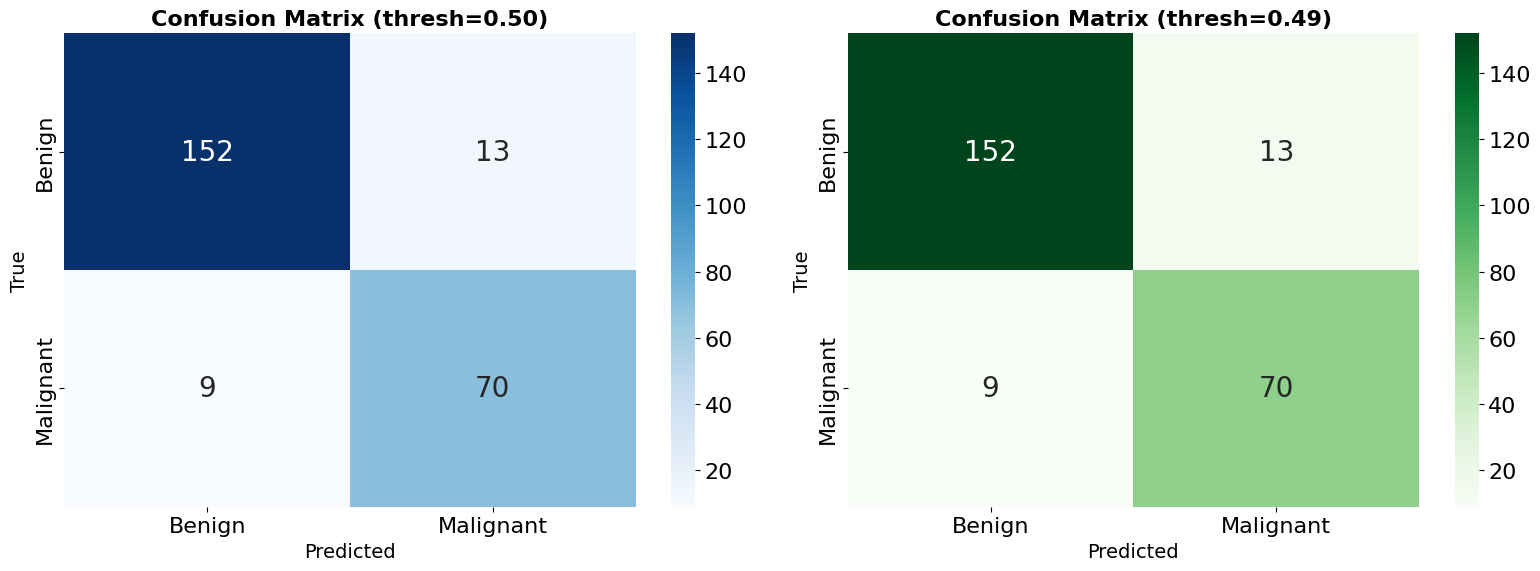

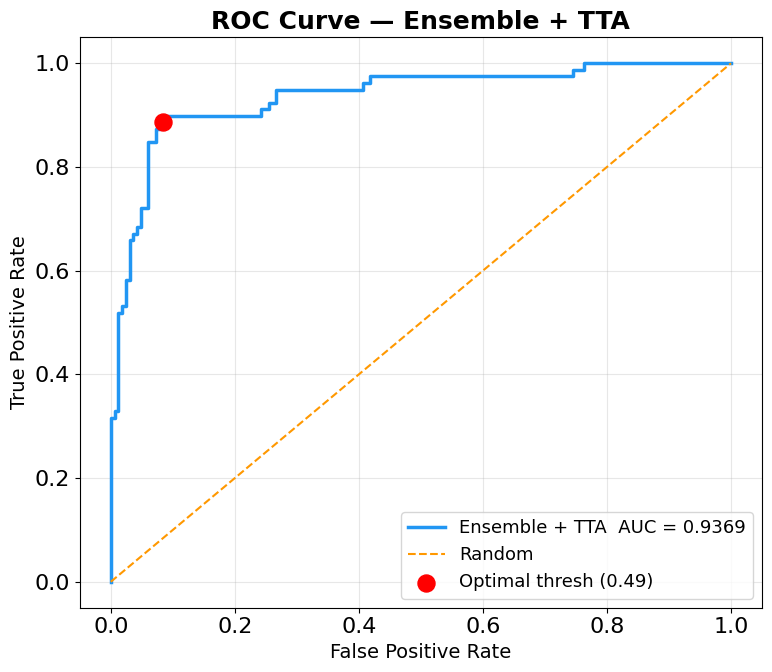

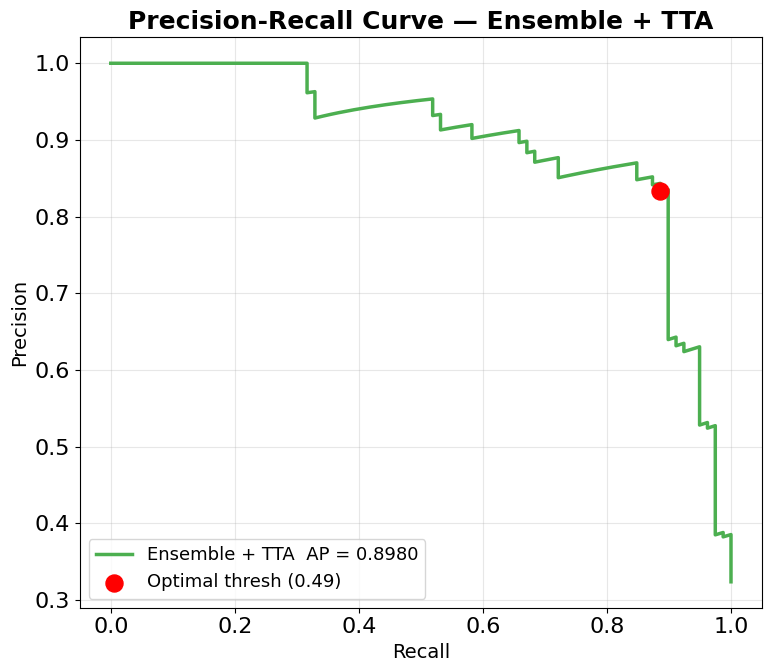


PER-FOLD TEST PERFORMANCE
  Fold 1: Acc=0.8730  F1=0.8144  AUC=0.9210
  Fold 2: Acc=0.8934  F1=0.8375  AUC=0.9233
  Fold 3: Acc=0.8770  F1=0.8125  AUC=0.9232
  Fold 4: Acc=0.8730  F1=0.8187  AUC=0.9219
  Fold 5: Acc=0.9016  F1=0.8481  AUC=0.9310

  Ensemble:  Acc=0.9098  F1=0.8642  AUC=0.9369
  Mean fold AUC: 0.9241 ± 0.0035


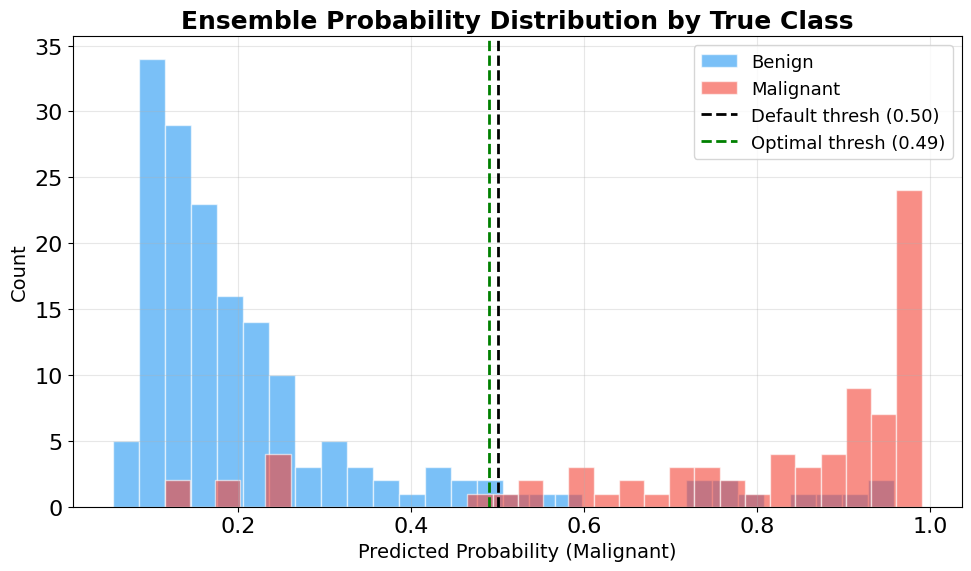

In [6]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve,
    average_precision_score, accuracy_score,
    f1_score, precision_score, recall_score, roc_auc_score
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── CONFIG (must match training) ──
SAVE_DIR     = "/kaggle/working/lidc_model_v6"
SMALL_PATH   = "/kaggle/input/datasets/senigarapuakash/lidc-idri-patches/X.npy"
LARGE_PATH   = "/kaggle/input/datasets/senigarapuakash/lidc-idri-patches/X_large.npy"
LABELS_PATH  = "/kaggle/input/datasets/senigarapuakash/lidc-idri-patches/y.npy"
RANDOM_SEED  = 42
TEST_SPLIT   = 0.15
N_FOLDS      = 5
BASE_FILTERS = 24
DROP_RATE    = 0.35
NUM_CLASSES  = 2

# ────────────────────────────────────────
# 1. LOAD DATA & SPLIT
# ────────────────────────────────────────
X_small = np.load(SMALL_PATH)
X_large = np.load(LARGE_PATH)
y = np.load(LABELS_PATH)

idx = np.arange(len(y))
trainval_idx, test_idx = train_test_split(
    idx, test_size=TEST_SPLIT, random_state=RANDOM_SEED, stratify=y
)

X_small_test = X_small[test_idx]
X_large_test = X_large[test_idx]
y_test = y[test_idx]

print(f"Test samples: {len(y_test)} (pos={np.sum(y_test==1)}, neg={np.sum(y_test==0)})")

# ────────────────────────────────────────
# 2. LOAD FOLD MODELS
# ────────────────────────────────────────
def load_fold_models():
    models = []
    for fold_idx in range(N_FOLDS):
        path = f"{SAVE_DIR}/best_fold{fold_idx}.pth"
        model = DualResNet3D_v6(num_classes=NUM_CLASSES, base_filters=BASE_FILTERS, drop_rate=DROP_RATE)
        ckpt = torch.load(path, map_location=device, weights_only=False)
        model.load_state_dict(ckpt["model_state_dict"])
        model = model.to(device)
        model.eval()
        models.append(model)
        print(f"  Fold {fold_idx+1}: epoch {ckpt['epoch']}, val_auc={ckpt['val_auc']:.4f}, val_acc={ckpt.get('val_acc',0):.4f}")
    return models

print("\nLoading fold models...")
fold_models = load_fold_models()

# ────────────────────────────────────────
# 3. TTA PREDICTION
# ────────────────────────────────────────
@torch.no_grad()
def predict_with_tta(model, x_small, x_large):
    """8-fold flip TTA."""
    model.eval()
    all_probs = []
    for fd in [False, True]:
        for fh in [False, True]:
            for fw in [False, True]:
                s, l = x_small.clone(), x_large.clone()
                if fd: s, l = torch.flip(s, [2]), torch.flip(l, [2])
                if fh: s, l = torch.flip(s, [3]), torch.flip(l, [3])
                if fw: s, l = torch.flip(s, [4]), torch.flip(l, [4])
                logits, _, _ = model(s, l, None)
                all_probs.append(F.softmax(logits, dim=1))
    return torch.stack(all_probs, dim=0).mean(dim=0)

@torch.no_grad()
def ensemble_predict_tta(fold_models, Xs, Xl):
    """Ensemble + TTA: average across all folds × 8 TTA flips."""
    all_fold_probs = []
    for fi, model in enumerate(fold_models):
        model.eval()
        fold_probs = []
        for i in range(len(Xs)):
            s = torch.tensor(Xs[i]).unsqueeze(0).unsqueeze(0).float().to(device)
            l = torch.tensor(Xl[i]).unsqueeze(0).unsqueeze(0).float().to(device)
            probs = predict_with_tta(model, s, l)
            fold_probs.append(probs[0, 1].cpu().item())
        all_fold_probs.append(np.array(fold_probs))
        print(f"  Fold {fi+1} done.")
    return np.mean(all_fold_probs, axis=0)

# ────────────────────────────────────────
# 4. RUN ENSEMBLE PREDICTION
# ────────────────────────────────────────
print("\nRunning ensemble + TTA predictions on test set...")
y_prob = ensemble_predict_tta(fold_models, X_small_test, X_large_test)
y_pred = (y_prob >= 0.5).astype(int)

# ────────────────────────────────────────
# 5. OPTIMAL THRESHOLD
# ────────────────────────────────────────
best_acc, best_thresh = 0.0, 0.5
for thresh in np.arange(0.30, 0.71, 0.01):
    preds = (y_prob >= thresh).astype(int)
    acc = accuracy_score(y_test, preds)
    if acc > best_acc:
        best_acc = acc
        best_thresh = thresh

y_pred_opt = (y_prob >= best_thresh).astype(int)

print(f"\nOptimal threshold: {best_thresh:.2f} (acc={best_acc:.4f})")

# ────────────────────────────────────────
# 6. METRICS SUMMARY
# ────────────────────────────────────────
print("\n" + "="*60)
print("TEST SET EVALUATION — ENSEMBLE + TTA")
print("="*60)

print(f"\n── With default threshold (0.50) ──")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"  F1 Score  : {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"  AUC       : {roc_auc_score(y_test, y_prob):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred, zero_division=0):.4f}")

print(f"\n── With optimal threshold ({best_thresh:.2f}) ──")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_opt):.4f}")
print(f"  F1 Score  : {f1_score(y_test, y_pred_opt, zero_division=0):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_opt, zero_division=0):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_opt, zero_division=0):.4f}")

# ────────────────────────────────────────
# 7. CLASSIFICATION REPORT
# ────────────────────────────────────────
print("\n" + "="*60)
print("CLASSIFICATION REPORT (Ensemble + TTA)")
print("="*60)
print(classification_report(
    y_test, y_pred,
    target_names=["Benign", "Malignant"],
    digits=4
))

print(f"\nWith optimal threshold ({best_thresh:.2f}):")
print(classification_report(
    y_test, y_pred_opt,
    target_names=["Benign", "Malignant"],
    digits=4
))

# ────────────────────────────────────────
# 8. CONFUSION MATRIX
# ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Default threshold
cm1 = confusion_matrix(y_test, y_pred)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=["Benign", "Malignant"],
            yticklabels=["Benign", "Malignant"],
            annot_kws={"size": 20})
axes[0].set_title("Confusion Matrix (thresh=0.50)", fontsize=16, fontweight="bold")
axes[0].set_xlabel("Predicted", fontsize=14)
axes[0].set_ylabel("True", fontsize=14)

# Optimal threshold
cm2 = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=["Benign", "Malignant"],
            yticklabels=["Benign", "Malignant"],
            annot_kws={"size": 20})
axes[1].set_title(f"Confusion Matrix (thresh={best_thresh:.2f})", fontsize=16, fontweight="bold")
axes[1].set_xlabel("Predicted", fontsize=14)
axes[1].set_ylabel("True", fontsize=14)

plt.tight_layout()
plt.show()

# ────────────────────────────────────────
# 9. ROC CURVE
# ────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(8, 7))
plt.plot(fpr, tpr, color='#2196F3', linewidth=2.5, label=f'Ensemble + TTA  AUC = {roc_auc_val:.4f}')
plt.plot([0, 1], [0, 1], '--', color='#FF9800', linewidth=1.5, label='Random')

# Mark optimal threshold point
opt_idx = np.argmin(np.abs(thresholds - best_thresh))
plt.scatter(fpr[opt_idx], tpr[opt_idx], s=150, color='red', zorder=5,
            label=f'Optimal thresh ({best_thresh:.2f})')

plt.title("ROC Curve — Ensemble + TTA", fontsize=18, fontweight="bold")
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.legend(fontsize=13, loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ────────────────────────────────────────
# 10. PRECISION-RECALL CURVE
# ────────────────────────────────────────
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

plt.figure(figsize=(8, 7))
plt.plot(recall_vals, precision_vals, color='#4CAF50', linewidth=2.5,
         label=f'Ensemble + TTA  AP = {ap:.4f}')

# Mark optimal threshold
opt_pr_idx = np.argmin(np.abs(pr_thresholds - best_thresh))
plt.scatter(recall_vals[opt_pr_idx], precision_vals[opt_pr_idx], s=150, color='red',
            zorder=5, label=f'Optimal thresh ({best_thresh:.2f})')

plt.title("Precision-Recall Curve — Ensemble + TTA", fontsize=18, fontweight="bold")
plt.xlabel("Recall", fontsize=14)
plt.ylabel("Precision", fontsize=14)
plt.legend(fontsize=13, loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ────────────────────────────────────────
# 11. PER-FOLD AUC COMPARISON
# ────────────────────────────────────────
print("\n" + "="*60)
print("PER-FOLD TEST PERFORMANCE")
print("="*60)

fold_aucs = []
for fi, model in enumerate(fold_models):
    model.eval()
    probs_i = []
    with torch.no_grad():
        for i in range(len(X_small_test)):
            s = torch.tensor(X_small_test[i]).unsqueeze(0).unsqueeze(0).float().to(device)
            l = torch.tensor(X_large_test[i]).unsqueeze(0).unsqueeze(0).float().to(device)
            logits, _, _ = model(s, l, None)
            probs_i.append(F.softmax(logits, dim=1)[0, 1].cpu().item())
    probs_i = np.array(probs_i)
    preds_i = (probs_i >= 0.5).astype(int)
    auc_i = roc_auc_score(y_test, probs_i)
    acc_i = accuracy_score(y_test, preds_i)
    f1_i  = f1_score(y_test, preds_i, zero_division=0)
    fold_aucs.append(auc_i)
    print(f"  Fold {fi+1}: Acc={acc_i:.4f}  F1={f1_i:.4f}  AUC={auc_i:.4f}")

print(f"\n  Ensemble:  Acc={accuracy_score(y_test, y_pred):.4f}  "
      f"F1={f1_score(y_test, y_pred, zero_division=0):.4f}  "
      f"AUC={roc_auc_score(y_test, y_prob):.4f}")
print(f"  Mean fold AUC: {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")

# ────────────────────────────────────────
# 12. CONFIDENCE DISTRIBUTION
# ────────────────────────────────────────
plt.figure(figsize=(10, 6))

benign_probs = y_prob[y_test == 0]
malig_probs  = y_prob[y_test == 1]

plt.hist(benign_probs, bins=30, alpha=0.6, color='#2196F3', label='Benign', edgecolor='white')
plt.hist(malig_probs,  bins=30, alpha=0.6, color='#F44336', label='Malignant', edgecolor='white')
plt.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Default thresh (0.50)')
plt.axvline(x=best_thresh, color='green', linestyle='--', linewidth=2,
            label=f'Optimal thresh ({best_thresh:.2f})')

plt.title("Ensemble Probability Distribution by True Class", fontsize=18, fontweight="bold")
plt.xlabel("Predicted Probability (Malignant)", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.legend(fontsize=13)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Loaded: Small=(1622, 16, 32, 32), Large=(1622, 32, 64, 64), Labels=(1622,)
Test samples: 244

Loading fold models...
  Loaded fold 1 (epoch 31, val_auc=0.9538)
  Loaded fold 2 (epoch 51, val_auc=0.9417)
  Loaded fold 3 (epoch 30, val_auc=0.9576)
  Loaded fold 4 (epoch 32, val_auc=0.9197)
  Loaded fold 5 (epoch 51, val_auc=0.8999)
Computing ensemble predictions...
Correct benign   : 149
Correct malignant: 70
Selected indices: [164, 138, 135, 121, 81, 75]
Using fold 3 for Grad-CAM generation


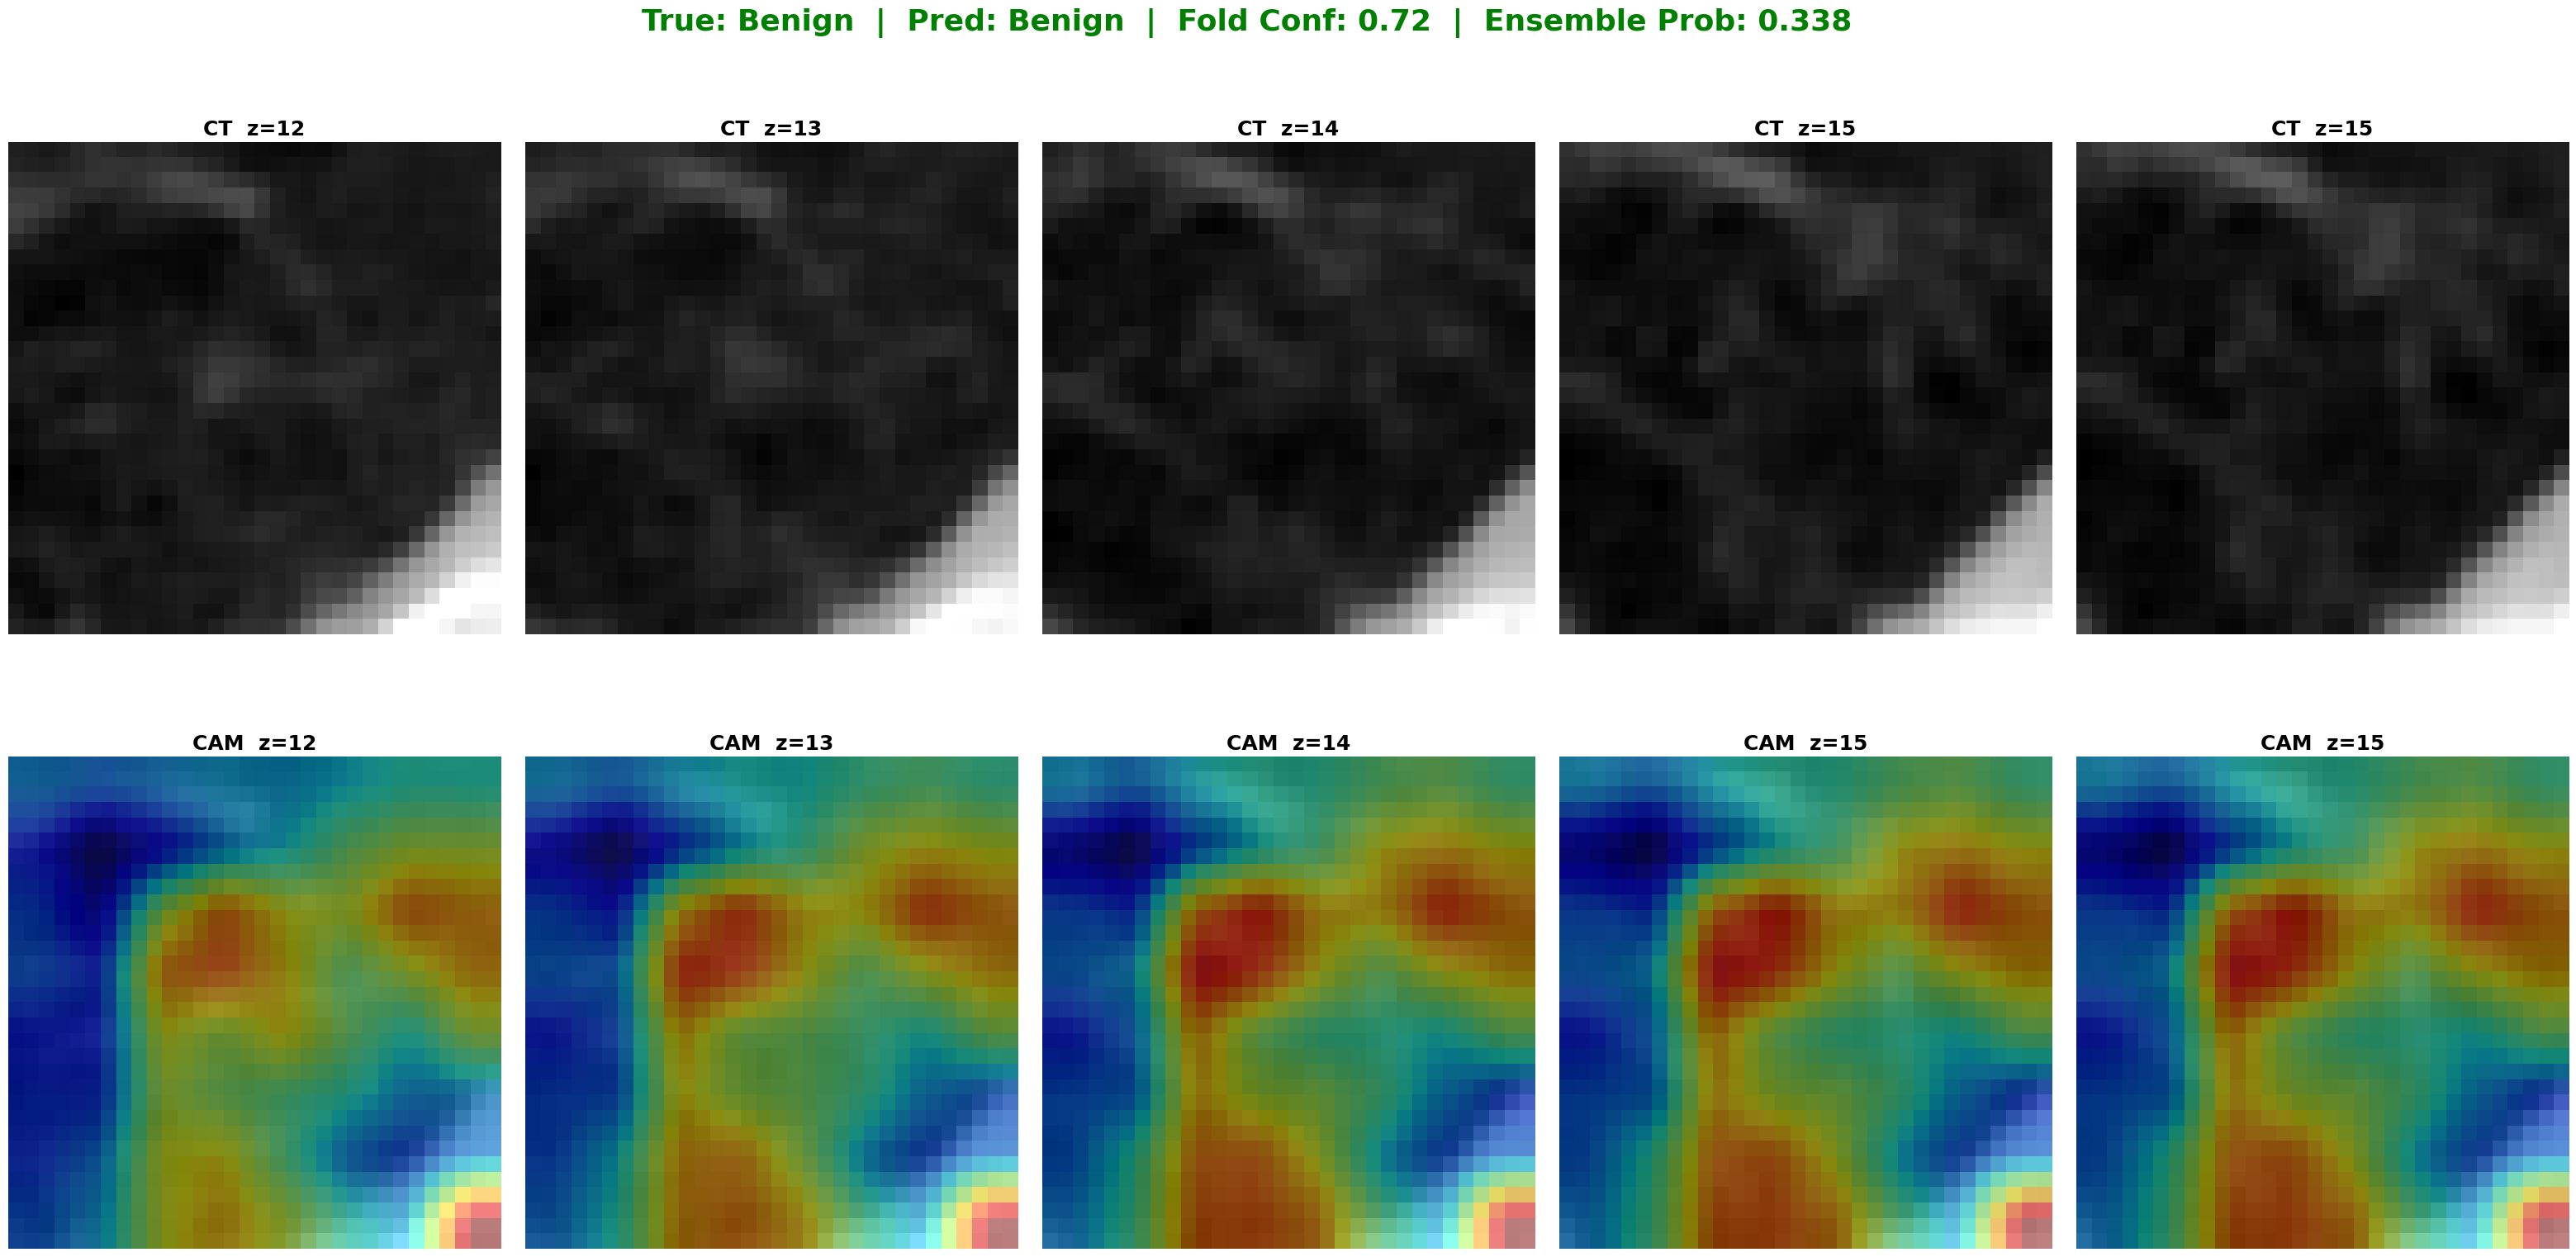

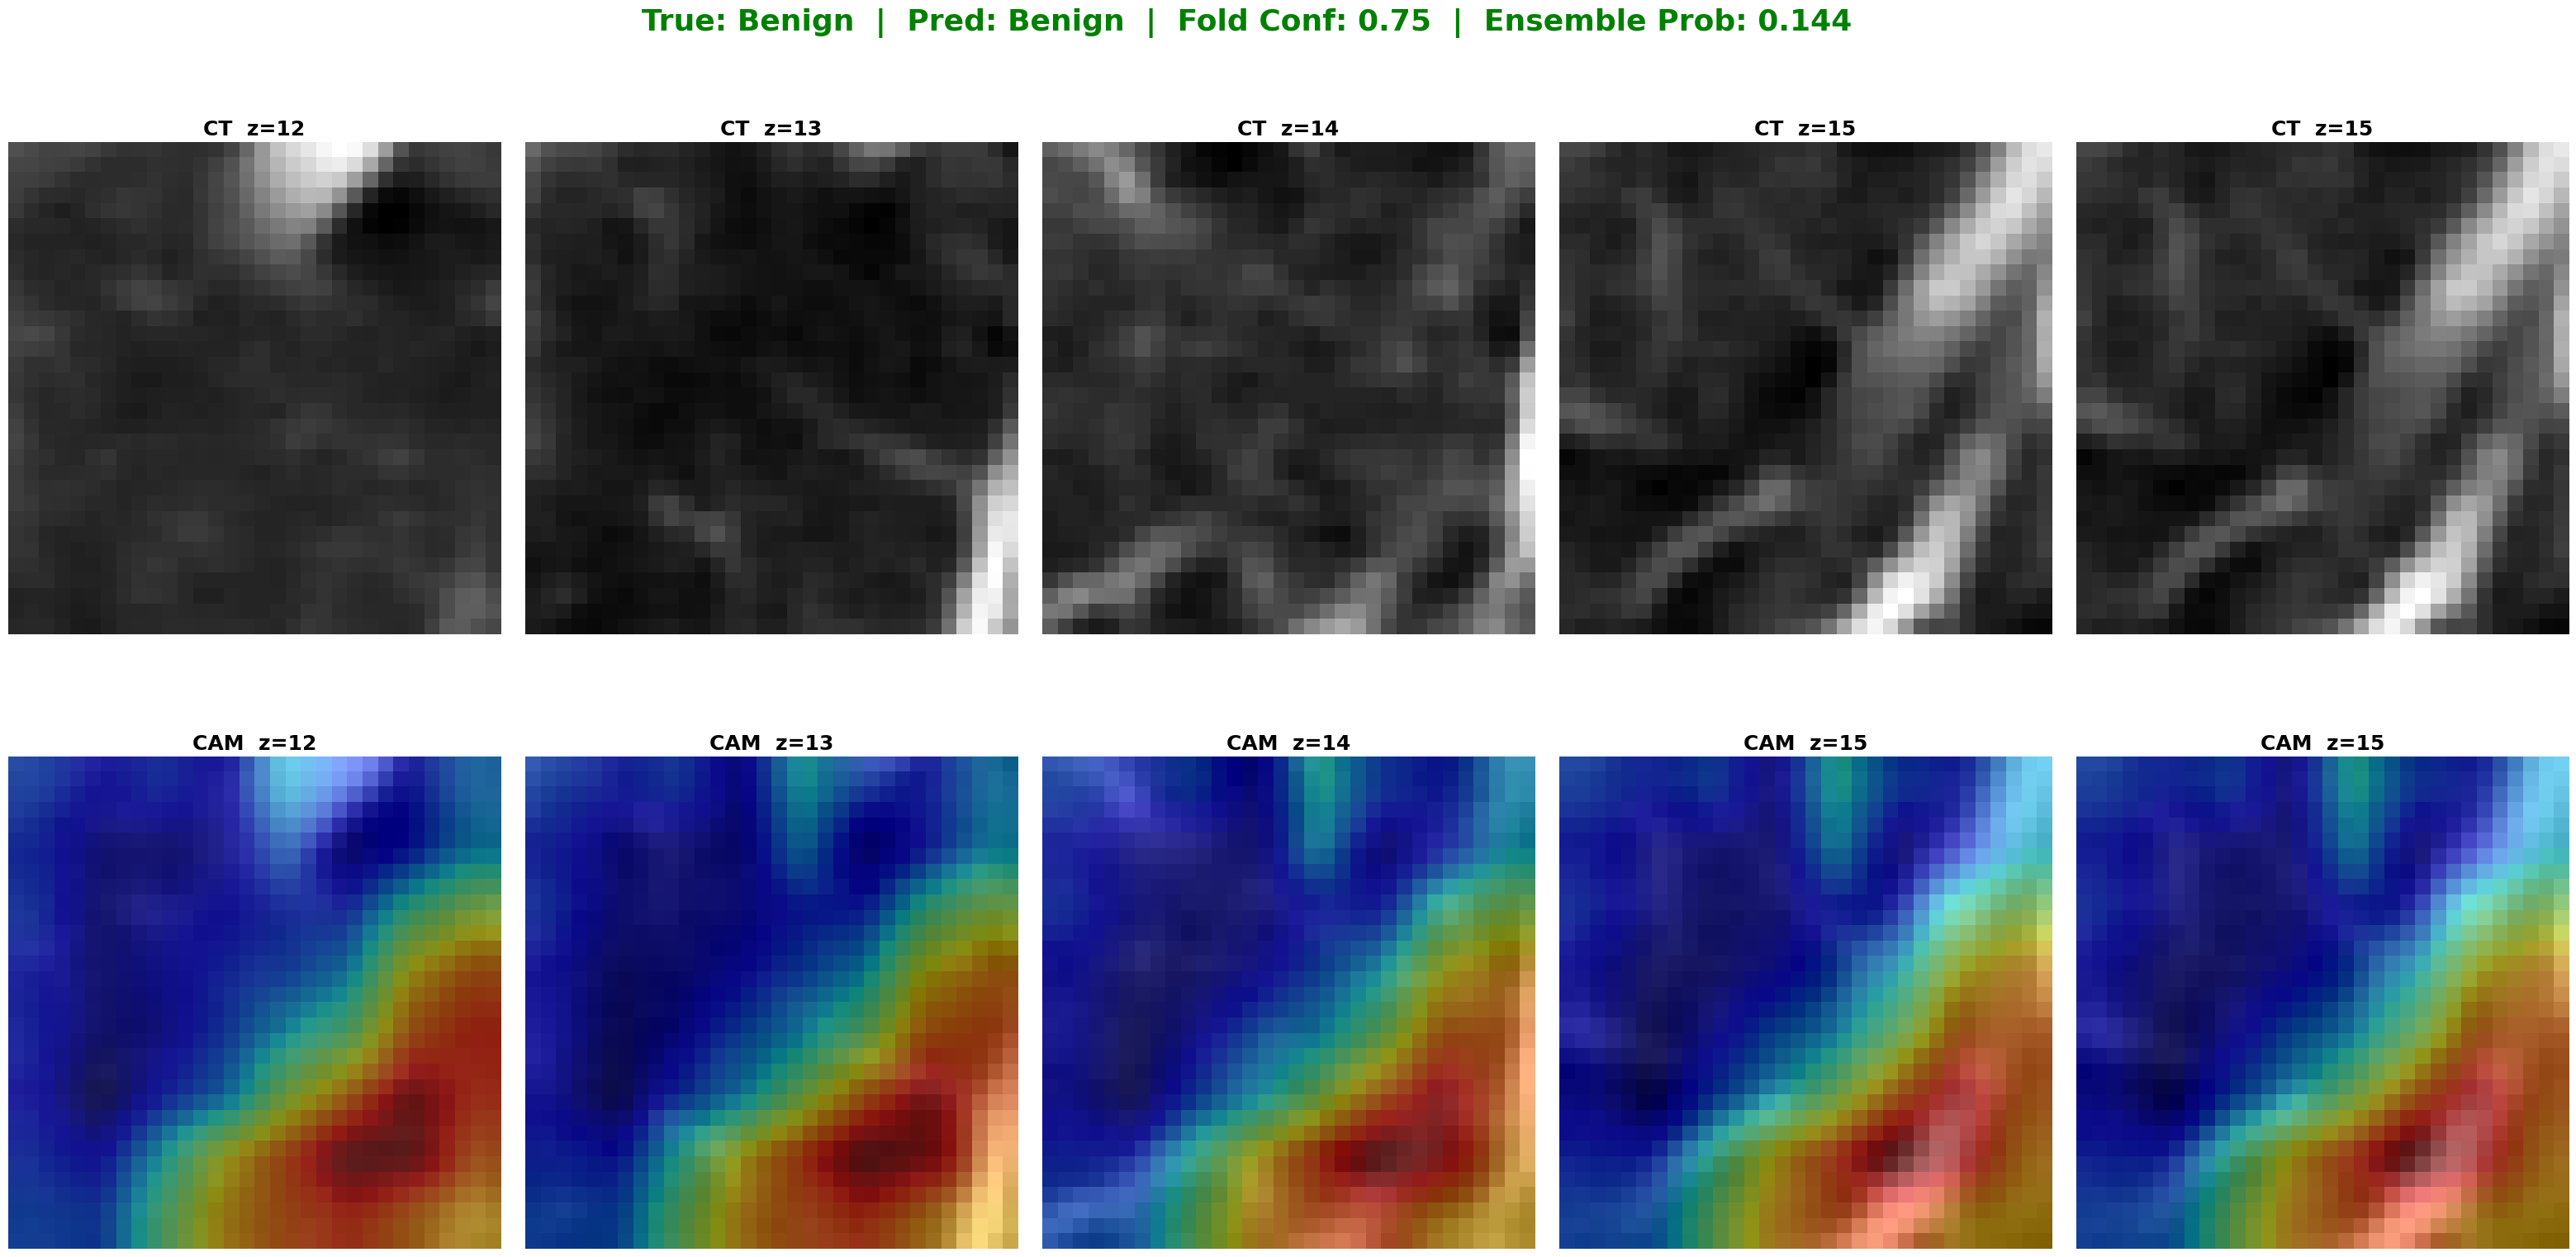

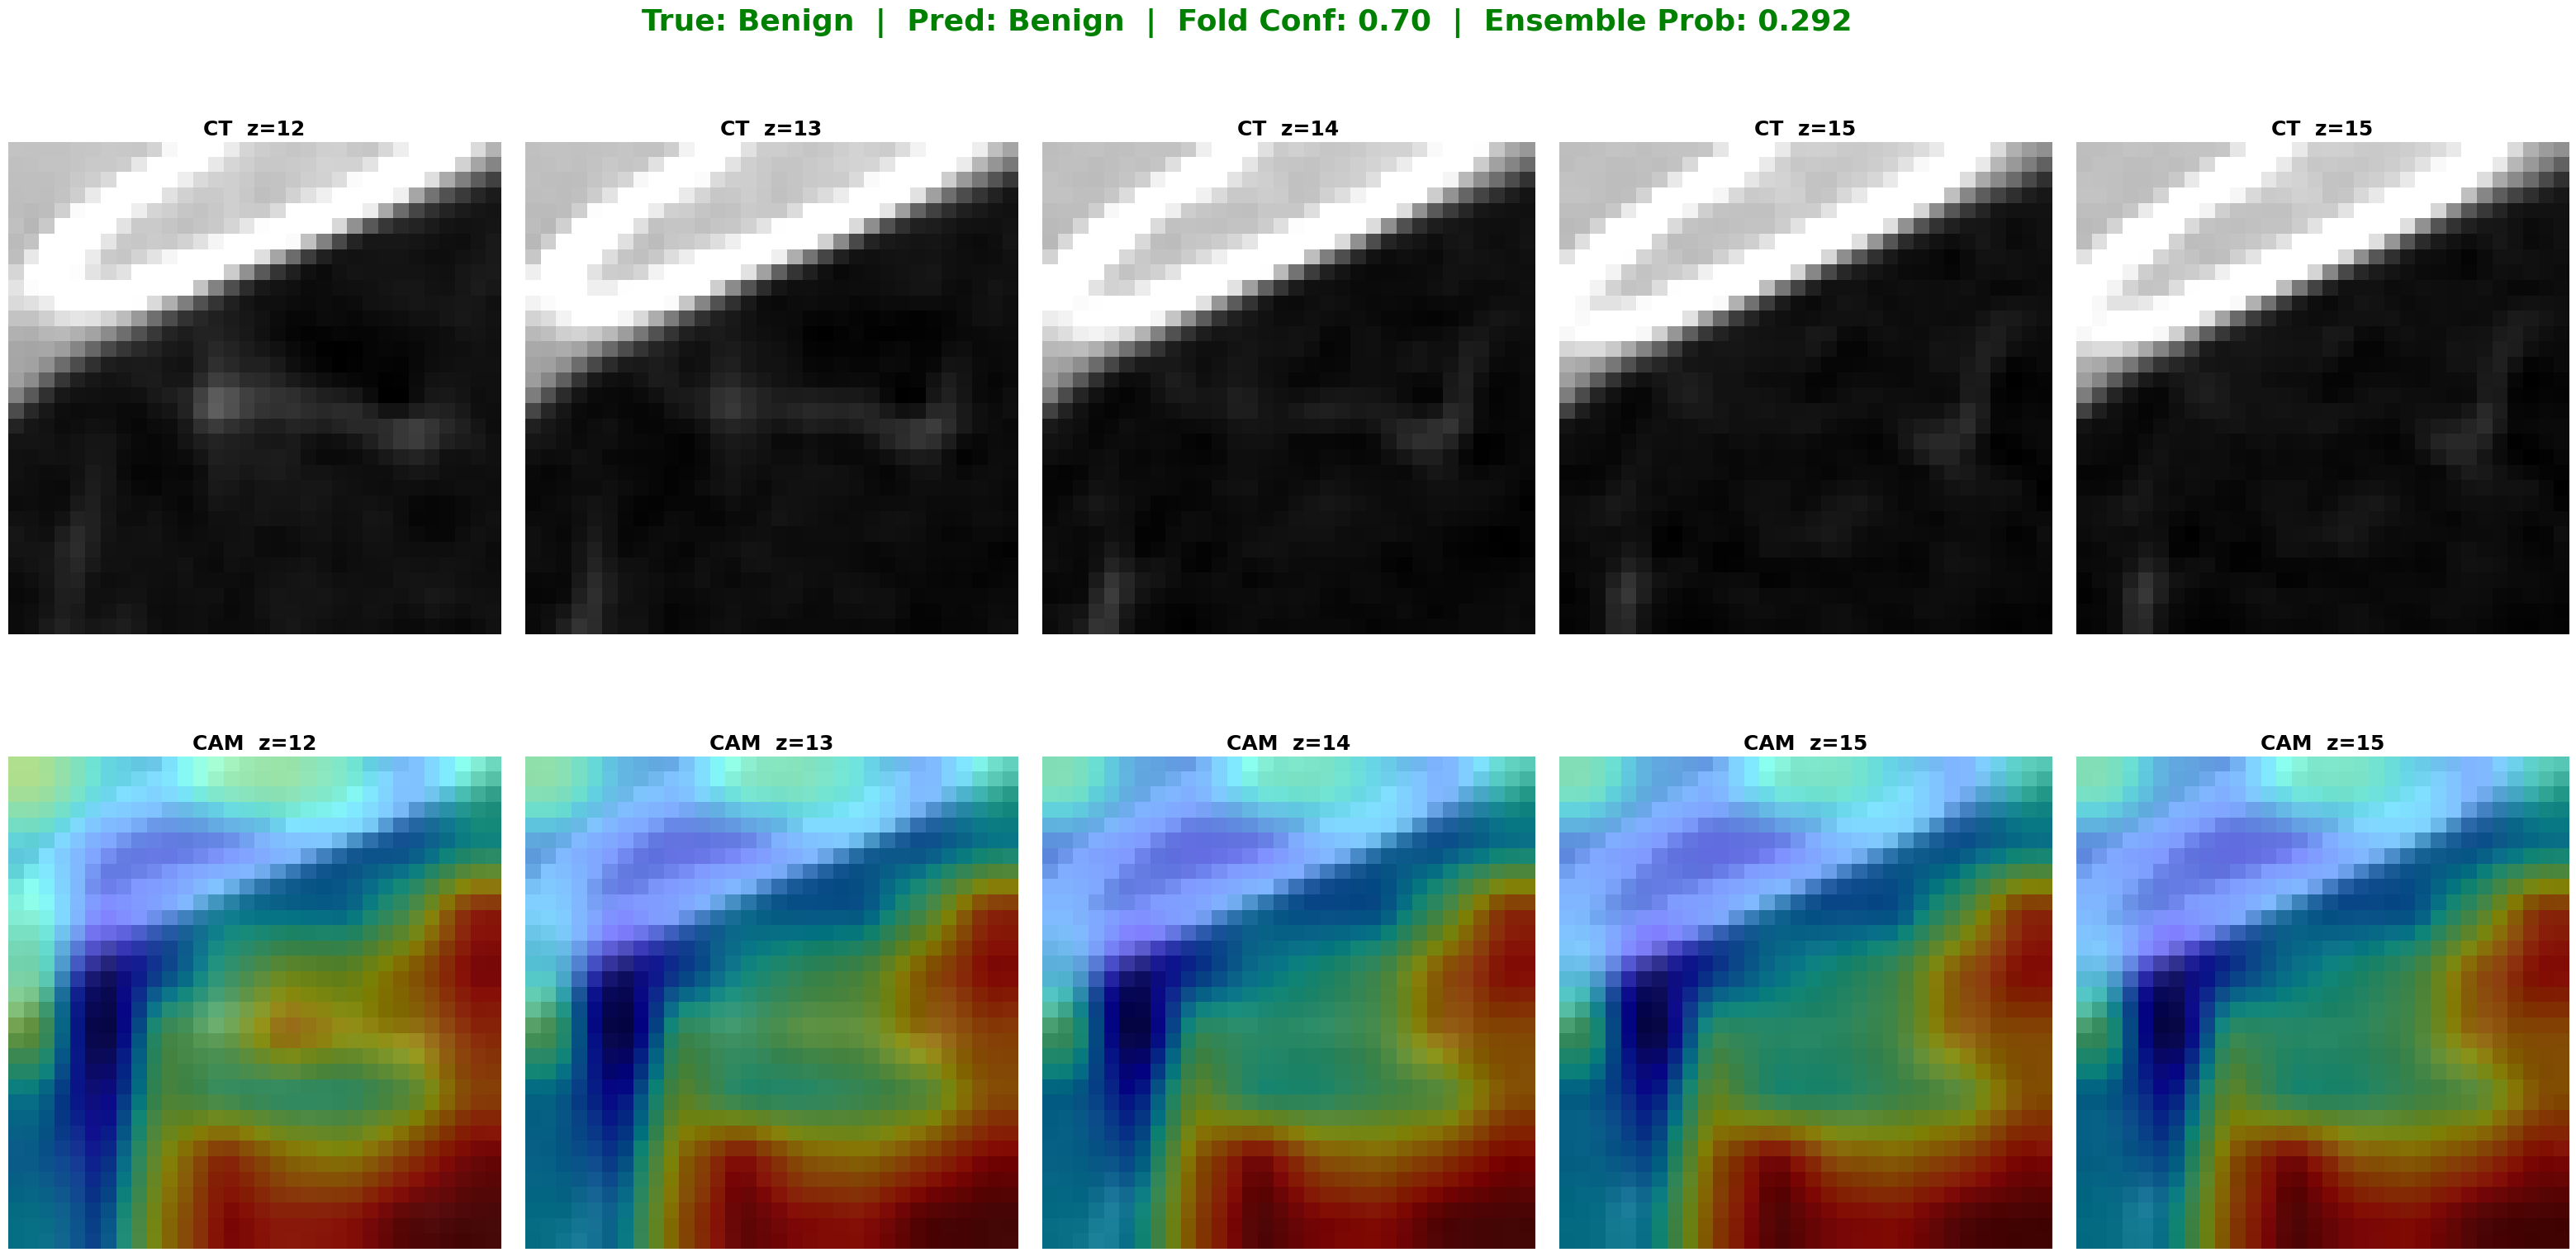

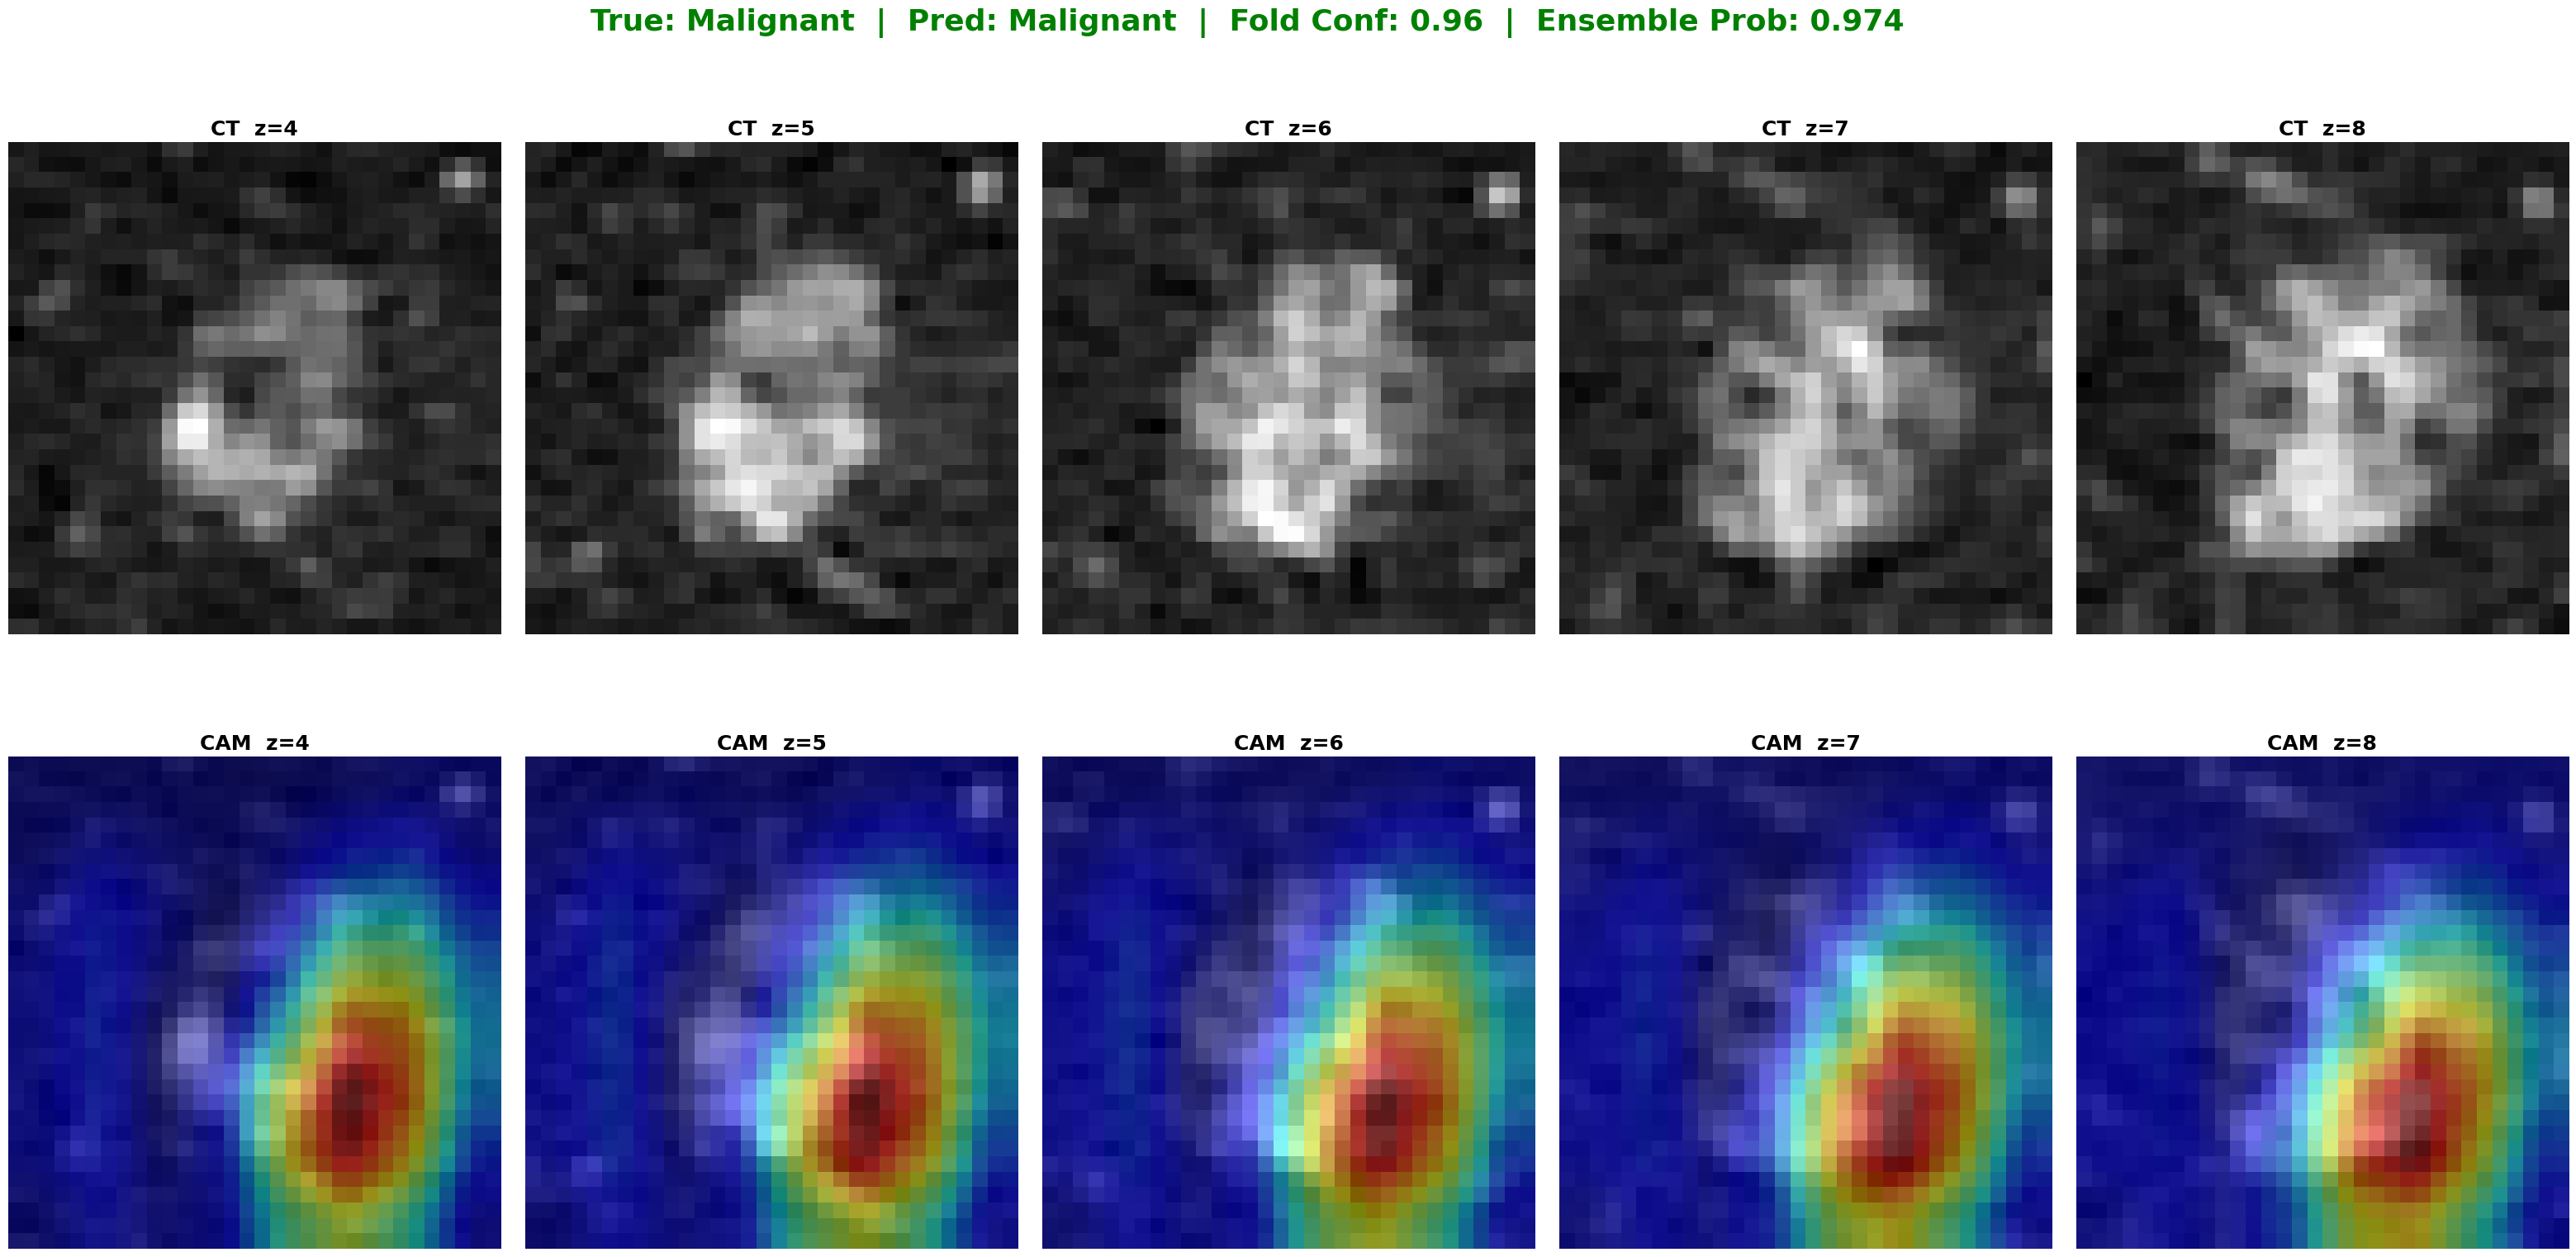

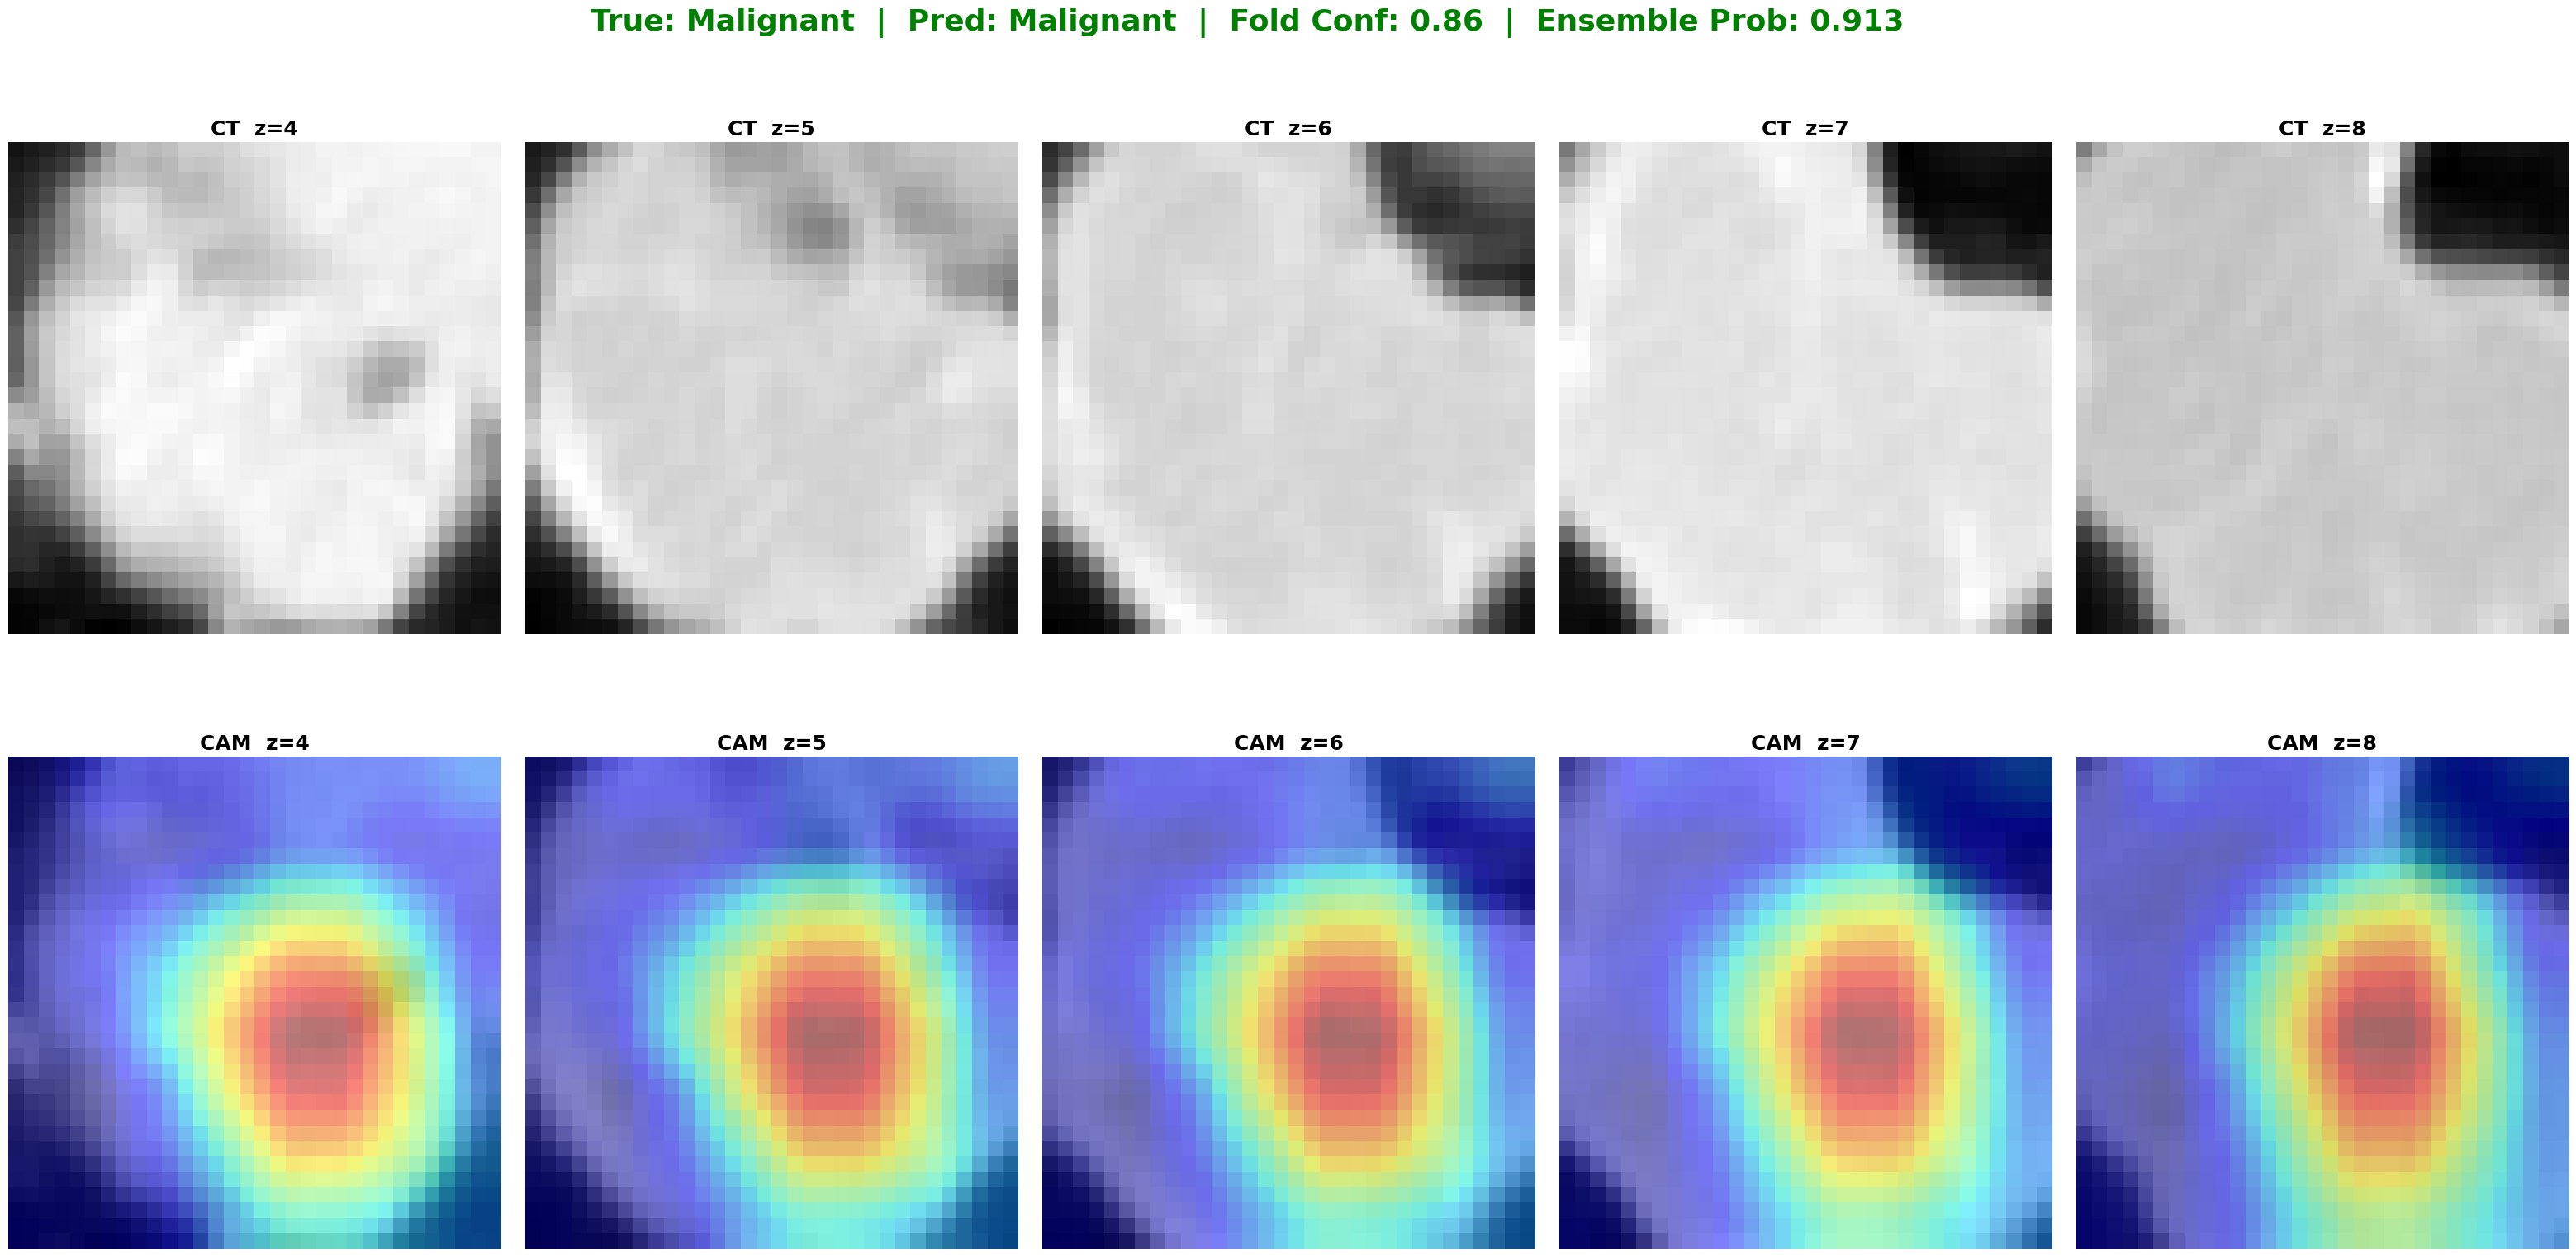

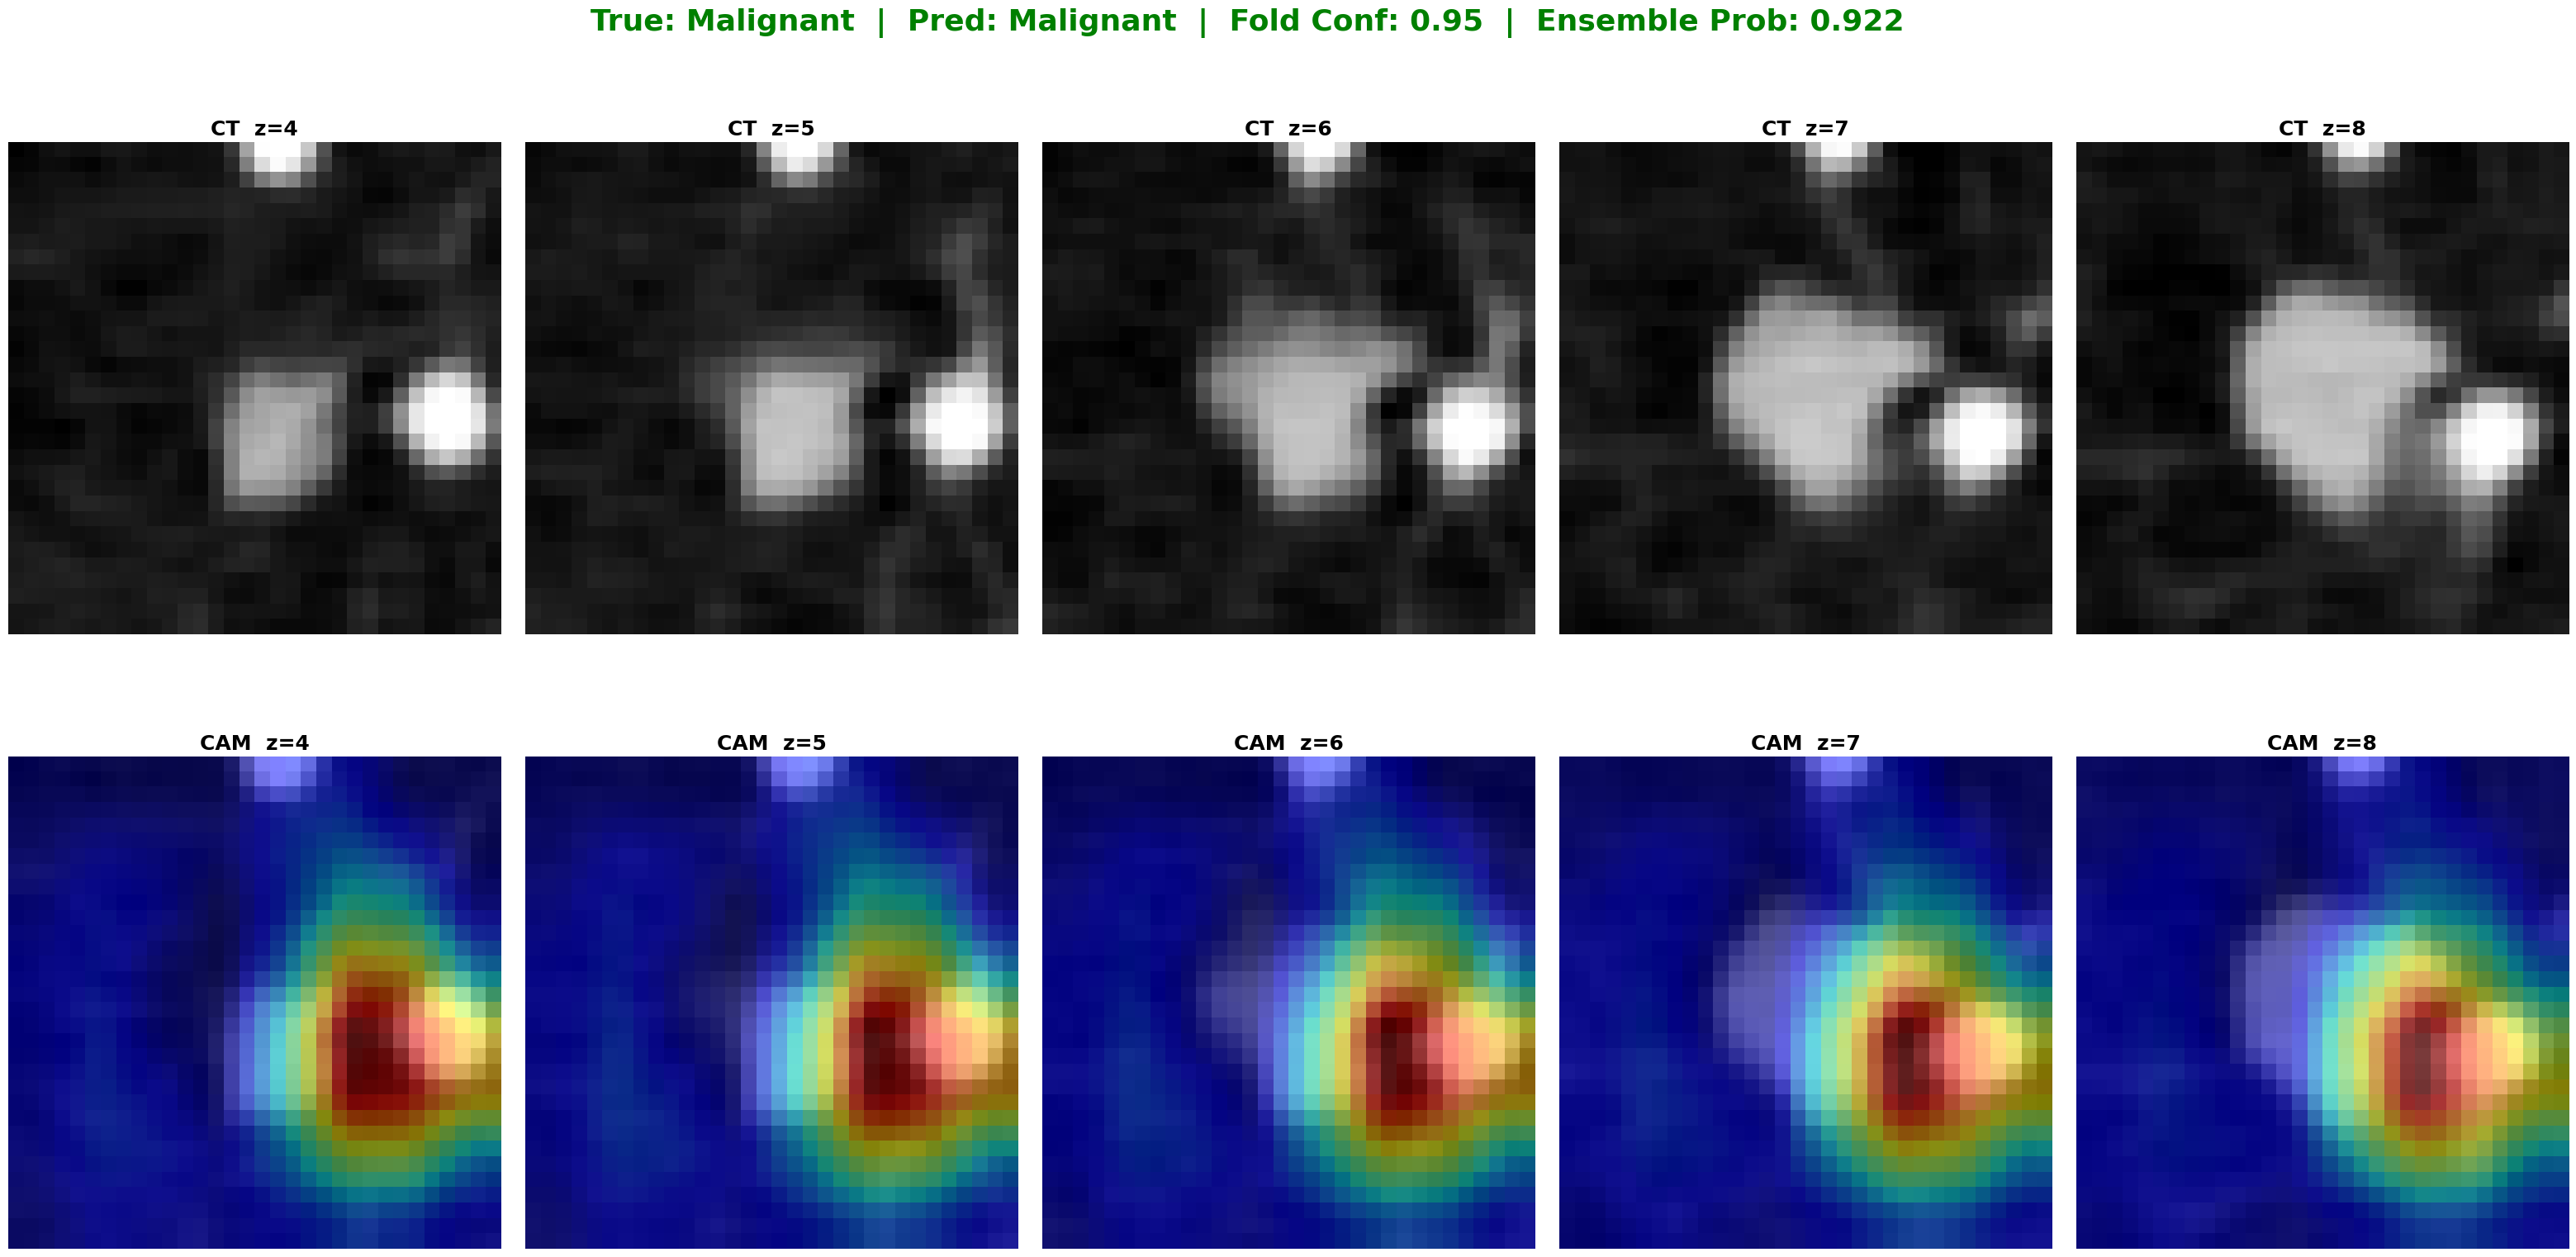

In [5]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── CONFIG (must match training) ──
SAVE_DIR    = "/kaggle/working/lidc_model_v6"
RANDOM_SEED = 42
TEST_SPLIT  = 0.15
N_FOLDS     = 5
BASE_FILTERS = 24
DROP_RATE    = 0.35
NUM_CLASSES  = 2

# =========================================================
# Grad-CAM++ using ONLY forward hooks (no backward hook errors)
# =========================================================
class GradCAM3DNoBackwardHook:
    def __init__(self, model, branch="small"):
        self.model = model
        self.branch = branch
        self.activations = None

        if branch == "large":
            self.layer = model.large_backbone.layer2
        else:
            self.layer = model.detail_backbone.layer2

        self._fh = self.layer.register_forward_hook(self._forward_hook)

    def _forward_hook(self, module, inputs, output):
        self.activations = output

    def generate(self, x_small, x_large):
        self.model.zero_grad(set_to_none=True)

        logits, _, _ = self.model(x_small, x_large, None)
        probs = F.softmax(logits, dim=1)
        pred = int(probs.argmax(dim=1).item())
        conf = float(probs[0, pred].item())

        score = logits[:, pred].sum()
        grads = torch.autograd.grad(
            outputs=score,
            inputs=self.activations,
            retain_graph=True,
            create_graph=False
        )[0]

        acts = self.activations

        # Grad-CAM++ weighting
        grads2 = grads ** 2
        grads3 = grads ** 3
        sum_acts = acts.sum(dim=(2, 3, 4), keepdim=True)
        alpha = grads2 / (2 * grads2 + sum_acts * grads3 + 1e-8)
        weights = (alpha * F.relu(grads)).sum(dim=(2, 3, 4), keepdim=True)

        cam = (weights * acts).sum(dim=1, keepdim=True)
        cam = F.relu(cam)

        target_size = x_small.shape[2:]
        cam = F.interpolate(cam, size=target_size, mode="trilinear", align_corners=False)

        cam = cam.squeeze().detach().cpu().numpy()
        cam = cam - cam.min()
        if cam.max() > 1e-8:
            cam = cam / cam.max()

        return cam, pred, conf

    def remove_hooks(self):
        self._fh.remove()


# =========================================================
# ENSEMBLE PREDICTION (to find correctly classified samples)
# =========================================================
@torch.no_grad()
def ensemble_predict(fold_models, X_small, X_large):
    """Average softmax probabilities across all fold models."""
    all_probs = []

    for model in fold_models:
        model.eval()
        probs_list = []
        for i in range(len(X_small)):
            s = torch.tensor(X_small[i]).unsqueeze(0).unsqueeze(0).float().to(device)
            l = torch.tensor(X_large[i]).unsqueeze(0).unsqueeze(0).float().to(device)
            logits, _, _ = model(s, l, None)
            probs_list.append(F.softmax(logits, dim=1)[0, 1].cpu().item())
        all_probs.append(np.array(probs_list))

    # Average across folds
    avg_probs = np.mean(all_probs, axis=0)
    preds = (avg_probs >= 0.5).astype(int)
    return preds, avg_probs


# =========================================================
# LOAD ALL FOLD MODELS
# =========================================================
def load_fold_models():
    """Load all 5 fold models."""
    models = []
    for fold_idx in range(N_FOLDS):
        path = f"{SAVE_DIR}/best_fold{fold_idx}.pth"
        model = DualResNet3D_v6(num_classes=NUM_CLASSES, base_filters=BASE_FILTERS, drop_rate=DROP_RATE)
        ckpt = torch.load(path, map_location=device, weights_only=False)
        model.load_state_dict(ckpt["model_state_dict"])
        model = model.to(device)
        model.eval()
        models.append(model)
        print(f"  Loaded fold {fold_idx+1} (epoch {ckpt['epoch']}, val_auc={ckpt['val_auc']:.4f})")
    return models


# =========================================================
# VISUALIZATION: Small branch only, 2 rows (CT + CAM)
# Uses ENSEMBLE prediction to filter correct samples,
# but Grad-CAM from the BEST single fold model.
# =========================================================
def show_gradcam_ensemble(fold_models, X_small, X_large, y, num_each=3, best_fold_idx=2):
    """
    fold_models: list of 5 fold models
    best_fold_idx: which fold model to use for Grad-CAM (0-indexed, default=2 = fold 3)
    """
    plt.rcParams.update({
        'font.size': 16,
        'axes.titlesize': 18,
        'figure.titlesize': 24,
    })

    print("Computing ensemble predictions...")
    y_pred, y_prob = ensemble_predict(fold_models, X_small, X_large)

    correct_idx = np.where(y_pred == y)[0]
    benign_idx = correct_idx[y[correct_idx] == 0]
    malignant_idx = correct_idx[y[correct_idx] == 1]

    print(f"Correct benign   : {len(benign_idx)}")
    print(f"Correct malignant: {len(malignant_idx)}")

    if len(benign_idx) < num_each or len(malignant_idx) < num_each:
        raise ValueError("Not enough correctly predicted benign or malignant samples.")

    np.random.seed(int(time.time()))
    benign_samples = np.random.choice(benign_idx, num_each, replace=False)
    malignant_samples = np.random.choice(malignant_idx, num_each, replace=False)
    selected = np.concatenate([benign_samples, malignant_samples])
    print("Selected indices:", selected.tolist())

    # Use the best fold model for Grad-CAM
    cam_model = fold_models[best_fold_idx]
    print(f"Using fold {best_fold_idx+1} for Grad-CAM generation")

    gcam = GradCAM3DNoBackwardHook(cam_model, branch="small")

    try:
        for idx in selected:
            s = torch.tensor(X_small[idx]).unsqueeze(0).unsqueeze(0).float().to(device)
            l = torch.tensor(X_large[idx]).unsqueeze(0).unsqueeze(0).float().to(device)

            cam_small, pred, conf = gcam.generate(s, l)

            # Get ensemble confidence
            ens_conf = y_prob[idx]

            true_label = int(y[idx])
            true_text = "Malignant" if true_label == 1 else "Benign"
            pred_text = "Malignant" if pred == 1 else "Benign"

            z_center = int(np.argmax(cam_small.sum(axis=(1, 2))))
            slices = [int(np.clip(z_center + off, 0, cam_small.shape[0] - 1)) for off in [-2, -1, 0, 1, 2]]

            fig = plt.figure(figsize=(40, 16))
            fig.suptitle(
                f"True: {true_text}  |  Pred: {pred_text}  |  "
                f"Fold Conf: {conf:.2f}  |  Ensemble Prob: {ens_conf:.3f}",
                fontsize=26,
                fontweight="bold",
                color="green" if true_label == pred else "red",
                y=0.98
            )

            # Row 1: CT slices
            for i, z in enumerate(slices):
                ax = fig.add_subplot(2, 5, i + 1)
                ax.imshow(X_small[idx][z], cmap="gray")
                ax.set_title(f"CT  z={z}", fontsize=18, fontweight="bold")
                ax.axis("off")

            # Row 2: CAM overlay
            for i, z in enumerate(slices):
                ax = fig.add_subplot(2, 5, i + 6)
                ax.imshow(X_small[idx][z], cmap="gray")
                ax.imshow(cam_small[z], cmap="jet", alpha=0.5)
                ax.set_title(f"CAM  z={z}", fontsize=18, fontweight="bold")
                ax.axis("off")

            plt.subplots_adjust(top=0.90, bottom=0.02, hspace=0.12, wspace=0.05)
            plt.show()

    finally:
        gcam.remove_hooks()


# ===================== RUN =====================
# 0. Load data
SMALL_PATH  = "/kaggle/input/datasets/senigarapuakash/lidc-idri-patches/X.npy"
LARGE_PATH  = "/kaggle/input/datasets/senigarapuakash/lidc-idri-patches/X_large.npy"
LABELS_PATH = "/kaggle/input/datasets/senigarapuakash/lidc-idri-patches/y.npy"

X_small = np.load(SMALL_PATH)
X_large = np.load(LARGE_PATH)
y = np.load(LABELS_PATH)
print(f"Loaded: Small={X_small.shape}, Large={X_large.shape}, Labels={y.shape}")

# 1. Get test split (same as training)
idx = np.arange(len(y))
trainval_idx, test_idx = train_test_split(
    idx, test_size=TEST_SPLIT, random_state=RANDOM_SEED, stratify=y
)

X_small_test = X_small[test_idx]
X_large_test = X_large[test_idx]
y_test = y[test_idx]

print(f"Test samples: {len(y_test)}")

# 2. Load all fold models
print("\nLoading fold models...")
fold_models = load_fold_models()

# 3. Visualize (uses fold 3 for Grad-CAM — best AUC=0.9576)
show_gradcam_ensemble(fold_models, X_small_test, X_large_test, y_test,
                      num_each=3, best_fold_idx=2)
